# Sprint 1e — Análise Temporal dos Regimes Operacionais (V1 × V2 × V3)

**Objetivo:** Avaliar a qualidade dos regimes identificados pelo clustering sob a perspectiva **temporal** — ou seja, verificar se os regimes se comportam como estados operacionais reais (persistentes e com padrões reconhecíveis) ou como artefatos ruidosos do algoritmo.

Compara a dinâmica temporal dos regimes identificados pelas 3 versões do clustering:
- **V1**: StandardScaler, 26 variáveis, 2 regimes
- **V2**: RobustScaler + Hampel, 16 variáveis curadas, 3 regimes
- **V3**: RobustScaler + feature engineering, 20 variáveis, 3 regimes

### O que procuramos nesta análise?

| Critério | Regime "bom" (estado real) | Regime "ruim" (artefato) |
|---|---|---|
| **Permanência** | Blocos longos (dezenas de min a horas) | Oscila a cada 1-2 minutos |
| **Transições** | Poucas por hora, previsíveis | Muitas por hora, aleatórias |
| **Padrão cíclico** | Variação por turno/hora coerente com operação | Sem padrão ou uniforme |
| **Estabilidade mensal** | Proporções consistentes ao longo dos meses | Variação errática |
| **Impacto energético** | Diferença mensurável entre regimes | Sem diferença significativa |

## 1. Setup: Caminhos e Imports

In [1]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys, os, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

# Caminhos padronizados
DATA_RAW    = PROJECT_ROOT / "data" / "raw"
DATA_PROC   = PROJECT_ROOT / "data" / "processed"
DATA_LABEL  = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR = PROJECT_ROOT / "figures" / "01_sprint1"
MODELS_DIR  = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# Imports
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import ListedColormap

from db_utils import carregar_dados, salvar_dataframe, salvar_imagem, criar_tabelas

# Criar schema e tabelas (idempotente)
criar_tabelas()

sns.set_theme(style="whitegrid", font_scale=0.9)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
STAGE = "s1e"

# ==============================================================================
# Configuração das 3 versões de clustering
# ==============================================================================
VERSOES = ["v1", "v2", "v3"]
VERSAO_LABELS = {"v1": "V1", "v2": "V2", "v3": "V3 (atual)"}
VERSAO_COLORS = {"v1": "#95a5a6", "v2": "#3498db", "v3": "#2ecc71"}

# Tabelas padronizadas no PostgreSQL
VERSAO_TABELAS = {
    "v1": "s1c_v1_dados_com_clusters",
    "v2": "s1c_v2_dados_com_clusters",
    "v3": "s1c_v3_dados_com_clusters",
}

# Fallback: parquets locais
VERSAO_PARQUETS = {
    "v1": DATA_PROC / "dados_com_clusters_v1.parquet",
    "v2": DATA_PROC / "dados_com_clusters_v2.parquet",
    "v3": DATA_PROC / "dados_com_clusters_v3.parquet",
}

# Cores por regime (Set2, suporta até 5 regimes)
REGIME_COLORS = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854"]

t0 = time.time()
print("=" * 60)
print("  S1e — ANÁLISE TEMPORAL DOS REGIMES (V1 × V2 × V3)")
print("=" * 60)

[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
  S1e — ANÁLISE TEMPORAL DOS REGIMES (V1 × V2 × V3)


## 2. Carga dos Dados — 3 Versões de Clustering

Carrega os datasets das 3 versões de clustering (PostgreSQL com fallback para parquet local). Cada dataset contém os dados originais do processo + a coluna `regime` atribuída pelo respectivo algoritmo.

Variáveis temporais auxiliares são criadas aqui para uso nas análises seguintes:
- `hora`, `dia_semana`, `mes`, `semana` — para análise de padrões cíclicos
- `turno` — Diurno (06h-18h) ou Noturno (18h-06h), seguindo a escala 4×4 da planta
- `transicao` — flag binária indicando mudança de regime em relação ao minuto anterior

In [2]:
# Carregar as 3 versões de clustering (PostgreSQL com fallback para parquet)
from db_utils import carregar_dados, carregar_dataframe

def _carregar_versao(ver):
    """Carrega dataset de uma versão: tenta banco, fallback para parquet."""
    tabela = VERSAO_TABELAS[ver]
    parquet = VERSAO_PARQUETS[ver]
    try:
        dv = carregar_dataframe(tabela)
        if len(dv) == 0:
            raise ValueError("Tabela vazia")
        origem = "banco"
    except Exception:
        dv = pd.read_parquet(parquet)
        origem = "parquet"
    return dv, origem

datasets = {}
for ver in VERSOES:
    dv, origem = _carregar_versao(ver)
    dv = dv.drop(columns=["id"], errors="ignore")
    dv["Timestamp"] = pd.to_datetime(dv["Timestamp"])
    dv = dv.set_index("Timestamp").sort_index()
    dv = dv[dv["regime"].notna()].copy()
    dv["regime"] = dv["regime"].astype(int)

    # Variáveis temporais auxiliares
    dv["hora"] = dv.index.hour
    dv["dia_semana"] = dv.index.dayofweek
    dv["dia_semana_nome"] = dv.index.day_name()
    dv["mes"] = dv.index.to_period("M")
    dv["semana"] = dv.index.isocalendar().week.values
    dv["turno"] = np.where((dv["hora"] >= 6) & (dv["hora"] < 18), "Diurno", "Noturno")

    # Coluna de transição — criada aqui para garantir disponibilidade em todas as análises
    dv["transicao"] = (dv["regime"].diff() != 0).astype(int)
    if len(dv) > 0:
        dv.loc[dv.index[0], "transicao"] = 0  # Primeiro registro não é transição

    datasets[ver] = dv
    n_reg = dv["regime"].nunique()
    regimes_str = sorted(dv["regime"].unique())
    print(f"\n{VERSAO_LABELS[ver]} ({origem}): {len(dv):,} registros, {n_reg} regimes {regimes_str}")
    for r in regimes_str:
        n = (dv["regime"] == r).sum()
        print(f"  Regime {r}: {n:>8,} ({100*n/len(dv):.1f}%)")

# Colunas de referência (iguais em todas as versões)
df_ref = datasets["v3"]
_cols_tph = [c for c in df_ref.columns if "BALANÇA" in c.upper()]
if not _cols_tph:
    raise ValueError("Nenhuma coluna com 'BALANÇA' encontrada no dataset.")
col_tph = _cols_tph[0]
col_pot = [c for c in df_ref.columns if "POTÊNCIA" in c.upper() or "POTENCIA" in c.upper()]
col_pot = col_pot[0] if col_pot else None

print(f"\nColuna TPH: {col_tph}")
print(f"Coluna Potência: {col_pot}")

[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.s1c_v1_dados_com_clusters

V1 (banco): 632,985 registros, 2 regimes [np.int64(0), np.int64(1)]
  Regime 0:  362,904 (57.3%)
  Regime 1:  270,081 (42.7%)
[db_utils] 632985 linhas carregadas de otimizar_moagem_aura.s1c_v2_dados_com_clusters

V2 (banco): 632,985 registros, 3 regimes [np.int64(0), np.int64(1), np.int64(2)]
  Regime 0:   90,119 (14.2%)
  Regime 1:  288,740 (45.6%)
  Regime 2:  254,126 (40.1%)
[db_utils] 632970 linhas carregadas de otimizar_moagem_aura.s1c_v3_dados_com_clusters

V3 (atual) (banco): 632,970 registros, 3 regimes [np.int64(0), np.int64(1), np.int64(2)]
  Regime 0:  343,783 (54.3%)
  Regime 1:   43,840 (6.9%)
  Regime 2:  245,347 (38.8%)

Coluna TPH: 1025_RETOMADA _ TR02 _ BALANÇA_pipoint
Coluna Potência: 1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint


## 3. Blocos Contíguos (Runs) — Permanência nos Regimes (V1 × V2 × V3)

**O que são blocos contíguos?** Cada "bloco" é uma sequência ininterrupta de minutos consecutivos em que a planta permanece no mesmo regime. Quanto mais longos os blocos, mais estável é o regime — e mais provável que represente um estado operacional real.

**Como interpretar os resultados:**

- **`n_blocos`**: Total de blocos daquele regime. Muitos blocos + baixa duração média = regime fragmentado (o modelo oscila entre classes).
- **`duração média` vs `mediana`**: Se a média é muito maior que a mediana, existem poucos blocos muito longos puxando a média para cima, enquanto a maioria dos blocos é curta. Isso indica distribuição assimétrica.
- **`≤5min`**: Percentual de blocos com duração de até 5 minutos. Valores altos (>60%) sugerem que o regime é ruidoso — o modelo atribui esse rótulo por poucos minutos antes de mudar.
- **`≥1h`**: Percentual de blocos com duração de pelo menos 1 hora. Valores acima de 10% indicam que o regime consegue se sustentar por períodos operacionalmente relevantes.

> **Regra prática:** Um bom regime operacional deveria ter mediana de duração acima de 10-15 minutos e pelo menos 5-10% de blocos com ≥1h.

In [3]:
# Identificar blocos contíguos (run-length encoding) para cada versão
blocos_por_versao = {}
stats_permanencia_por_versao = {}

for ver in VERSOES:
    dv = datasets[ver]
    regime_series = dv["regime"].values
    mudancas = np.diff(regime_series, prepend=regime_series[0] - 1) != 0
    bloco_id = np.cumsum(mudancas)
    dv["bloco_id"] = bloco_id

    blocos = dv.groupby("bloco_id").agg(
        regime=("regime", "first"),
        inicio=("regime", lambda x: x.index[0] if len(x) > 0 else pd.NaT),
        fim=("regime", lambda x: x.index[-1] if len(x) > 0 else pd.NaT),
        duracao_min=("regime", "count"),
    ).reset_index()
    blocos["duracao_h"] = blocos["duracao_min"] / 60
    blocos_por_versao[ver] = blocos

    stats = []
    for r in sorted(blocos["regime"].unique()):
        b = blocos[blocos["regime"] == r]["duracao_min"]
        stats.append({
            "regime": r, "nome": f"Regime {r}",
            "n_blocos": len(b), "duracao_min_min": b.min(),
            "duracao_mediana_min": b.median(),
            "duracao_media_min": round(b.mean(), 1),
            "duracao_max_min": b.max(),
            "duracao_media_h": round(b.mean() / 60, 1),
            "duracao_max_h": round(b.max() / 60, 1),
            "pct_blocos_curtos_5min": round(100 * (b <= 5).sum() / len(b), 1),
            "pct_blocos_longos_1h": round(100 * (b >= 60).sum() / len(b), 1),
        })
    stats_permanencia_por_versao[ver] = pd.DataFrame(stats)

    print(f"\n{'=' * 60}")
    print(f"  {VERSAO_LABELS[ver]}: {len(blocos):,} blocos | {len(blocos)-1:,} transições")
    print(f"{'=' * 60}")
    for _, row in pd.DataFrame(stats).iterrows():
        r = int(row["regime"])
        print(f"  R{r}: {int(row['n_blocos']):,} blocos | "
              f"média={row['duracao_media_min']:.0f}min | "
              f"mediana={row['duracao_mediana_min']:.0f}min | "
              f"max={row['duracao_max_min']:.0f}min ({row['duracao_max_h']:.1f}h) | "
              f"≤5min: {row['pct_blocos_curtos_5min']:.0f}% | ≥1h: {row['pct_blocos_longos_1h']:.0f}%")


  V1: 7,773 blocos | 7,772 transições
  R0: 3,887 blocos | média=93min | mediana=2min | max=126809min (2113.5h) | ≤5min: 79% | ≥1h: 5%
  R1: 3,886 blocos | média=70min | mediana=3min | max=7917min (132.0h) | ≤5min: 62% | ≥1h: 13%

  V2: 15,915 blocos | 15,914 transições
  R0: 2,496 blocos | média=36min | mediana=2min | max=17582min (293.0h) | ≤5min: 82% | ≥1h: 3%
  R1: 6,685 blocos | média=43min | mediana=2min | max=17078min (284.6h) | ≤5min: 75% | ≥1h: 6%
  R2: 6,734 blocos | média=38min | mediana=2min | max=4466min (74.4h) | ≤5min: 73% | ≥1h: 8%

  V3 (atual): 28,855 blocos | 28,854 transições
  R0: 10,833 blocos | média=32min | mediana=3min | max=2156min (35.9h) | ≤5min: 62% | ≥1h: 11%
  R1: 8,265 blocos | média=5min | mediana=4min | max=99min (1.6h) | ≤5min: 69% | ≥1h: 0%
  R2: 9,757 blocos | média=25min | mediana=3min | max=2576min (42.9h) | ≤5min: 62% | ≥1h: 10%


### 3.1 — Distribuição de Duração dos Blocos (V1 × V2 × V3)

**Gráficos à esquerda (histogramas):** Mostram a distribuição de duração dos blocos (limitada a 300min = 5h para visualização). Um pico forte próximo a 0 indica que a maioria dos blocos é muito curta. Caudas longas à direita indicam que alguns blocos duram horas — esses são os períodos de operação estável.

**Gráficos à direita (boxplots, escala log):** Comparam a dispersão da duração entre regimes na mesma versão. A escala logarítmica permite visualizar desde blocos de 1 minuto até blocos de centenas de horas. A linha central do box é a **mediana** — se estiver abaixo de 10 min, o regime típico é muito curto.

**O que observar:**
- Se todos os regimes têm distribuições similares → o modelo não distingue bem estados com dinâmicas diferentes
- Se um regime tem mediana muito menor que os outros → pode ser um "regime de transição" (estado intermediário entre os regimes principais)

[db_utils] Imagem 'duracao_blocos' salva para etapa s1e


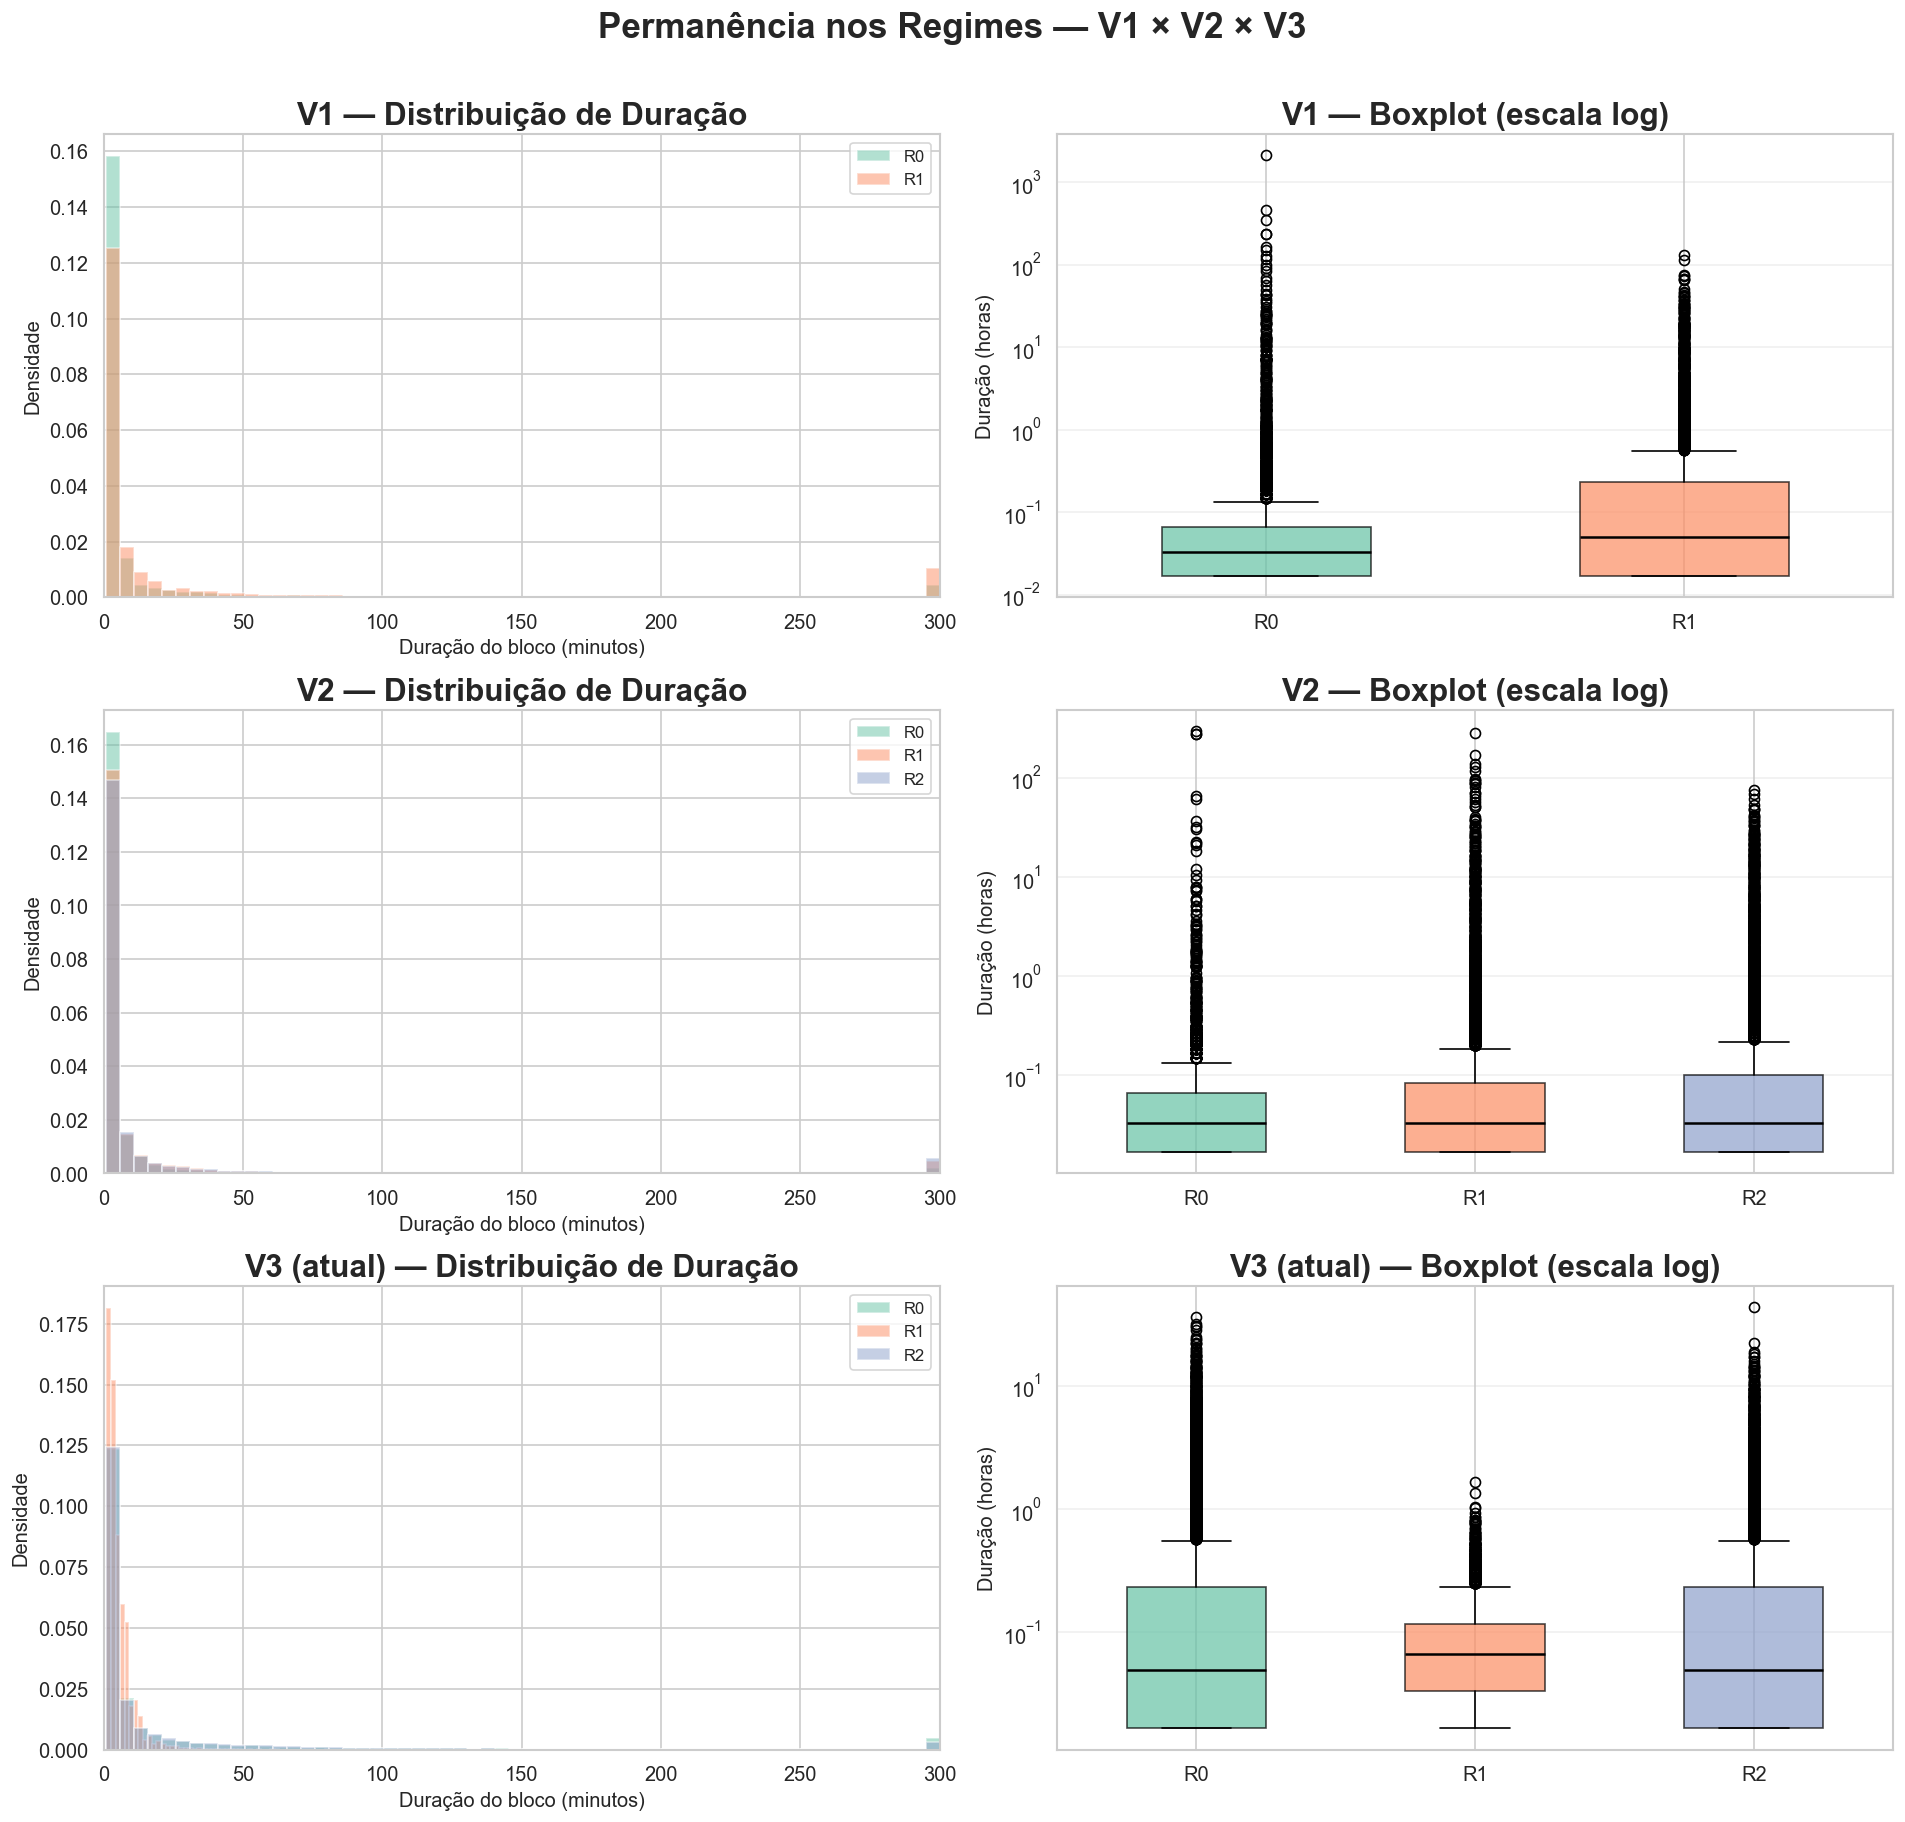

In [4]:
fig, axes = plt.subplots(len(VERSOES), 2, figsize=(16, 5 * len(VERSOES)))

for row, ver in enumerate(VERSOES):
    blocos = blocos_por_versao[ver]
    regimes_sorted = sorted(blocos["regime"].unique())

    # Histograma de duração (limitado a 300min = 5h)
    ax = axes[row, 0]
    for r in regimes_sorted:
        data = blocos[blocos["regime"] == r]["duracao_min"].clip(upper=300)
        ax.hist(data, bins=60, alpha=0.5, color=REGIME_COLORS[r],
                label=f"R{r}", density=True)
    ax.set_xlabel("Duração do bloco (minutos)")
    ax.set_ylabel("Densidade")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Distribuição de Duração", fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(0, 300)

    # Boxplot comparativo (escala log)
    ax = axes[row, 1]
    data_box = [blocos[blocos["regime"] == r]["duracao_h"].values for r in regimes_sorted]
    bp = ax.boxplot(data_box, labels=[f"R{r}" for r in regimes_sorted],
                    patch_artist=True, widths=0.5)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(REGIME_COLORS[regimes_sorted[i]])
        patch.set_alpha(0.7)
    for m in bp["medians"]:
        m.set_color("black")
        m.set_linewidth(1.5)
    ax.set_ylabel("Duração (horas)")
    ax.set_yscale("log")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Boxplot (escala log)", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Permanência nos Regimes — V1 × V2 × V3", fontsize=21, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1e_01_duracao_blocos.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "duracao_blocos", fig, "S1e_01_duracao_blocos.png")
plt.show()

## 4. Matriz de Transição (Markov) — V1 × V2 × V3

**O que é a matriz de transição?** Dado que a planta está no regime X neste minuto, qual a probabilidade de estar em cada regime no minuto seguinte? Isso modela a dinâmica como uma cadeia de Markov de 1ª ordem.

**Como interpretar:**

- **Diagonal principal (auto-transição):** Probabilidade de **permanecer** no mesmo regime. Valores acima de 97% indicam regimes muito estáveis — a planta fica minutos a horas no mesmo estado antes de mudar. Valores abaixo de 90% indicam regime instável / transitório.
- **Fora da diagonal:** Probabilidade de **mudar** para outro regime. Valores muito baixos (<1%) são esperados — transições devem ser eventos raros se os regimes representam estados operacionais reais.
- **Simetria das transições:** Se P(A→B) ≈ P(B→A), os regimes são intercambiáveis. Se P(A→B) >> P(B→A), existe uma direção preferencial (ex: degradação gradual de um estado para outro).

In [5]:
# Calcular transições entre regimes consecutivos para cada versão
trans_matrices = {}

for ver in VERSOES:
    dv = datasets[ver]
    regime_series = dv["regime"].values
    regime_atual = regime_series[:-1]
    regime_proximo = regime_series[1:]

    regimes_unicos = sorted(dv["regime"].unique())
    regime_to_idx = {r: i for i, r in enumerate(regimes_unicos)}
    n_reg = len(regimes_unicos)
    trans_count = np.zeros((n_reg, n_reg), dtype=int)
    for i in range(len(regime_atual)):
        r_from = regime_to_idx.get(regime_atual[i])
        r_to = regime_to_idx.get(regime_proximo[i])
        if r_from is not None and r_to is not None:
            trans_count[r_from, r_to] += 1

    trans_prob = trans_count / trans_count.sum(axis=1, keepdims=True)

    labels = [f"R{r}" for r in regimes_unicos]
    trans_matrices[ver] = {
        "count": pd.DataFrame(trans_count, index=labels, columns=labels),
        "prob": pd.DataFrame(np.round(trans_prob, 4), index=labels, columns=labels),
        "prob_raw": trans_prob,
        "n_regimes": n_reg,
        "regimes": regimes_unicos,
    }

    n_trans_diff = trans_count.sum() - np.diag(trans_count).sum()
    print(f"\n{'=' * 50} {VERSAO_LABELS[ver]} {'=' * 10}")
    print(f"Transições entre regimes diferentes: {n_trans_diff:,}")
    print("Probabilidade de permanência:", end="  ")
    for j, r in enumerate(regimes_unicos):
        print(f"R{r}: {trans_prob[j,j]*100:.2f}%", end="  ")
    print()


================================================== V1 ==========
Transições entre regimes diferentes: 7,772
Probabilidade de permanência:  R0: 98.93%  R1: 98.56%  

================================================== V2 ==========
Transições entre regimes diferentes: 15,914
Probabilidade de permanência:  R0: 97.23%  R1: 97.68%  R2: 97.35%  

================================================== V3 (atual) ==========
Transições entre regimes diferentes: 28,854
Probabilidade de permanência:  R0: 96.85%  R1: 81.15%  R2: 96.02%  


### 4.1 — Visualização da Matriz de Transição (V1 × V2 × V3)

**Gráficos à esquerda (heatmaps):** Mostram a matriz de probabilidades de transição. Cores quentes na diagonal = boa permanência. Cores quentes fora da diagonal = transições frequentes (problema).

**Gráficos à direita (barras):** Mostram a probabilidade de **sair** do regime a cada minuto (= 1 - auto-transição). Quanto menor a barra, mais estável o regime.

**O que observar:**
- Se um regime tem barra muito maior que os outros → ele é instável e pode ser um "regime de passagem" entre os estados principais
- Comparar entre versões: a versão com barras mais uniformes e baixas tem regimes mais coerentes temporalmente

[db_utils] Imagem 'matriz_transicao' salva para etapa s1e


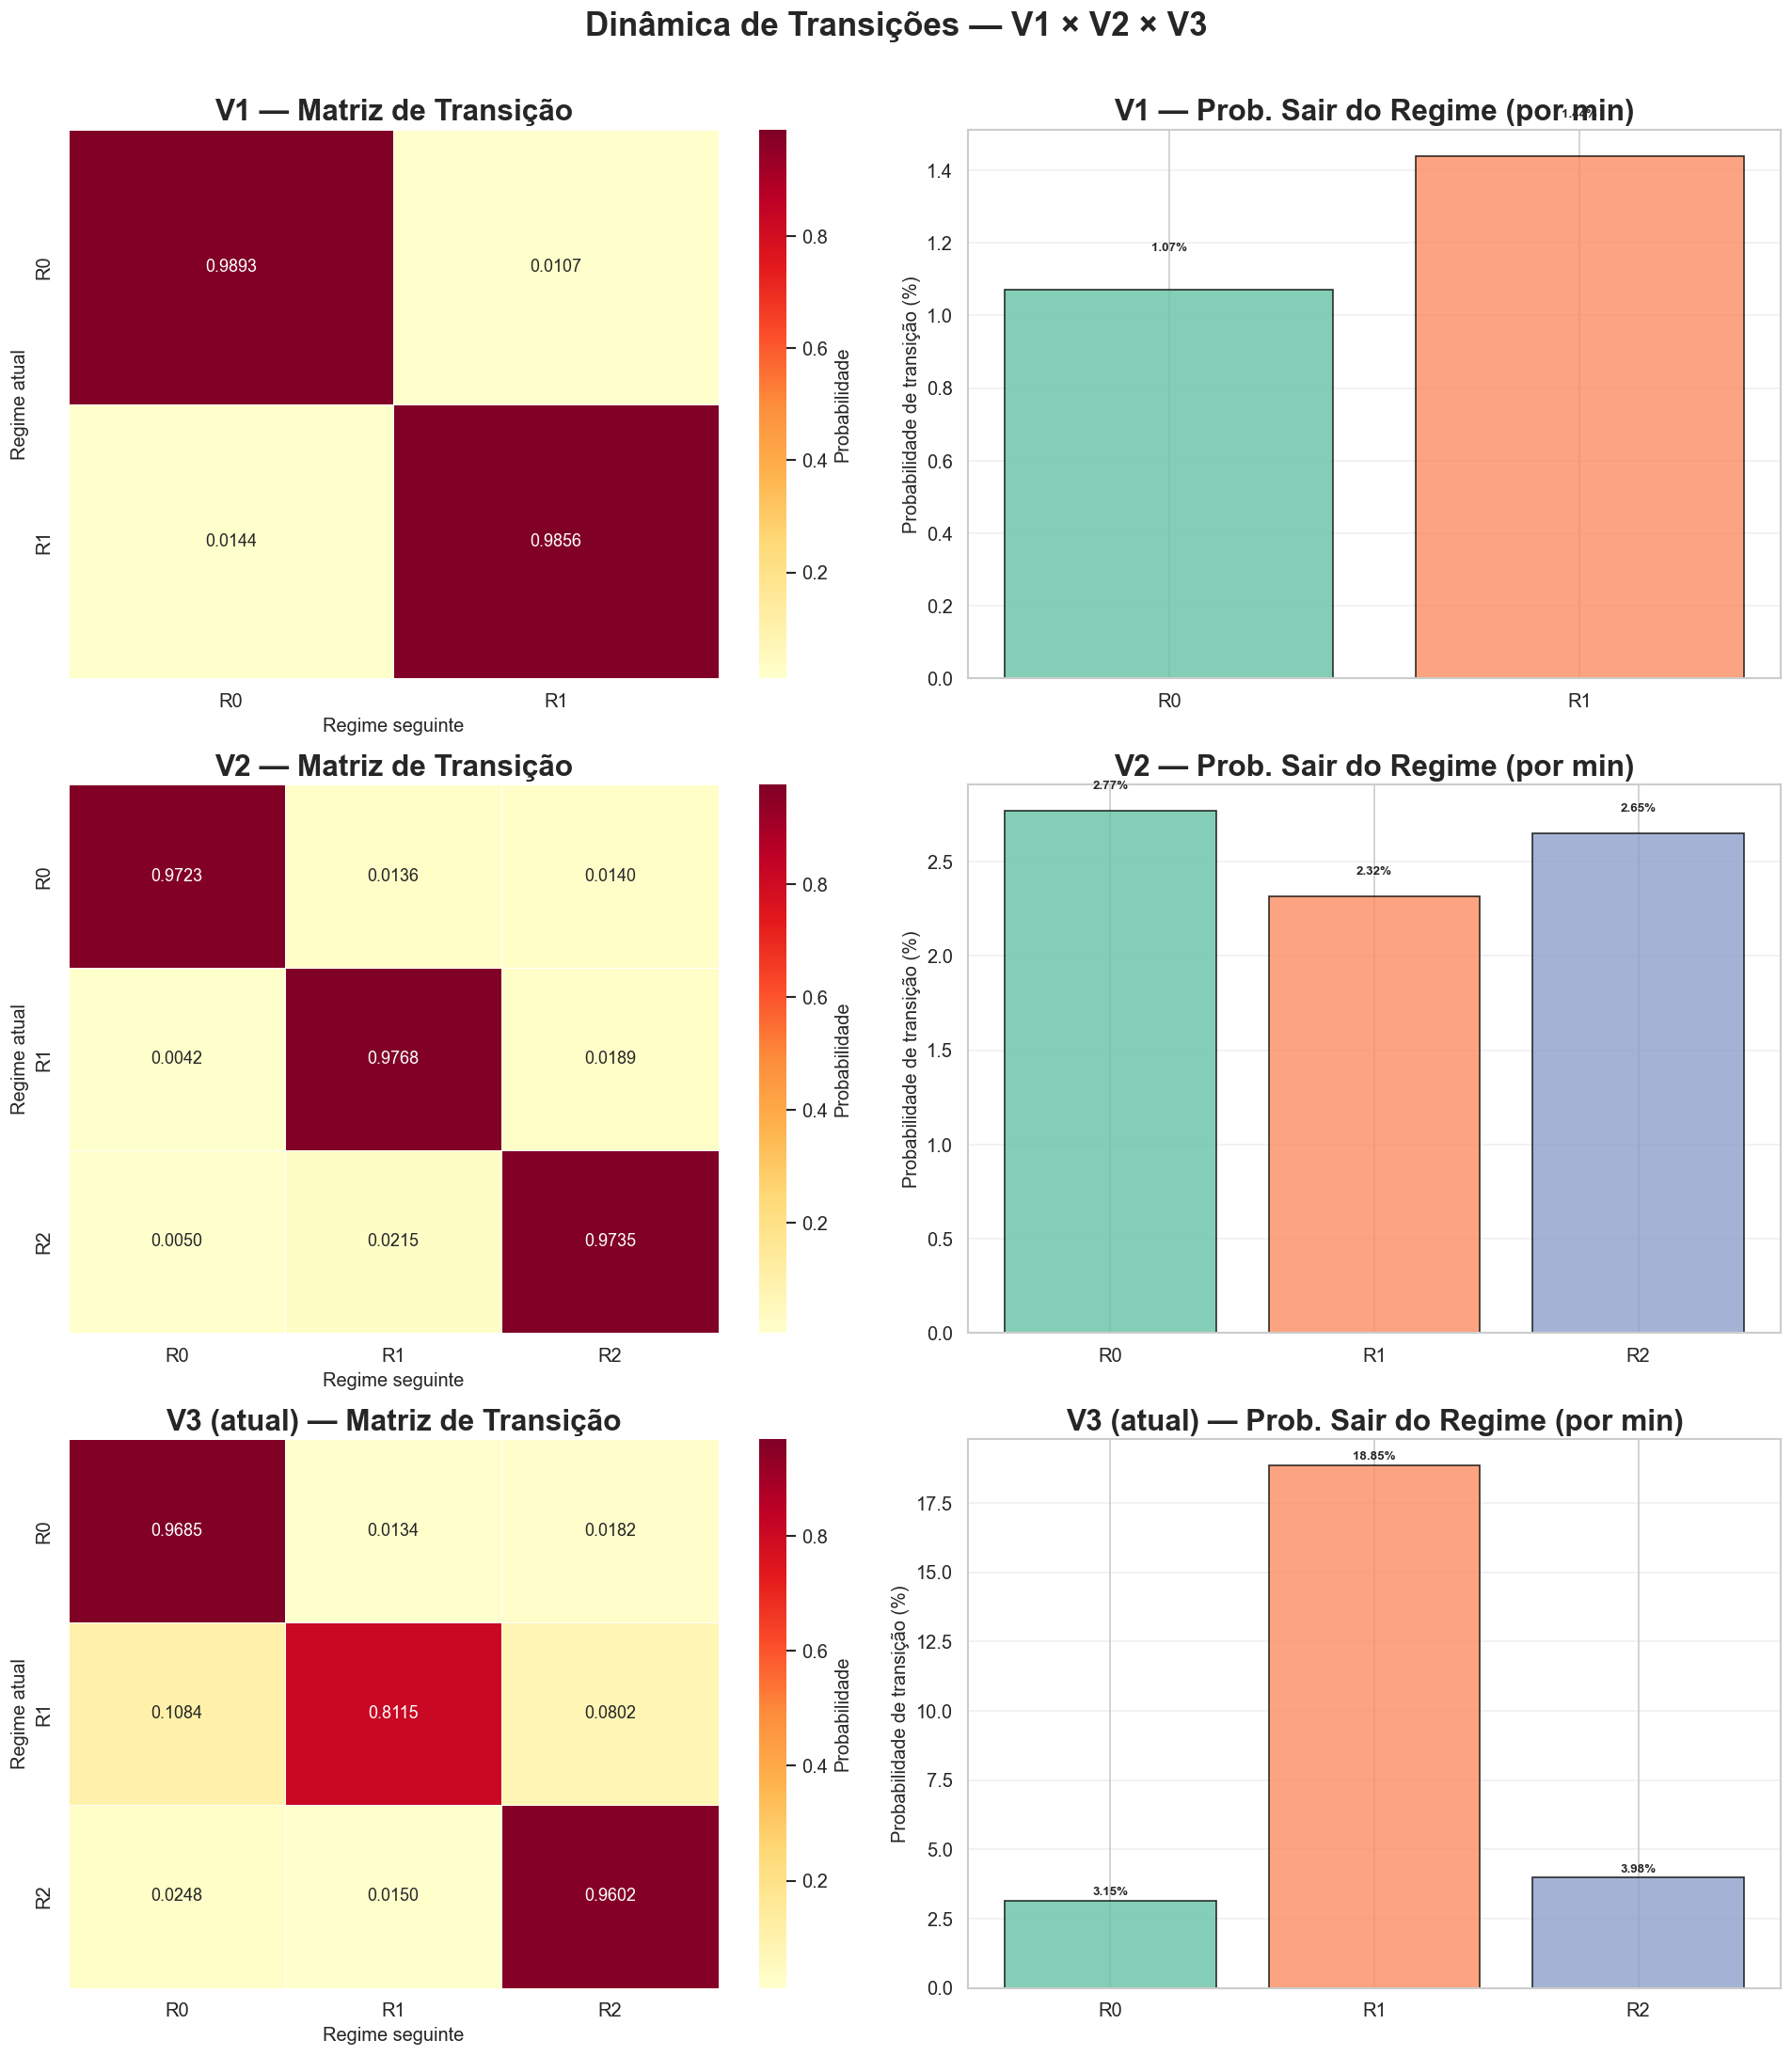

In [6]:
fig, axes = plt.subplots(len(VERSOES), 2, figsize=(16, 6 * len(VERSOES)))

for row, ver in enumerate(VERSOES):
    tm = trans_matrices[ver]
    trans_prob = tm["prob_raw"]
    regimes = tm["regimes"]
    n_reg = tm["n_regimes"]

    # Heatmap da matriz de probabilidade
    ax = axes[row, 0]
    sns.heatmap(trans_prob, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax,
                xticklabels=[f"R{r}" for r in regimes],
                yticklabels=[f"R{r}" for r in regimes],
                linewidths=0.5, cbar_kws={"label": "Probabilidade"})
    ax.set_xlabel("Regime seguinte")
    ax.set_ylabel("Regime atual")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Matriz de Transição", fontweight="bold")

    # Barras: probabilidade de SAIR de cada regime
    ax = axes[row, 1]
    prob_sair = 1 - np.diag(trans_prob)
    colors = [REGIME_COLORS[r] for r in regimes]
    bars = ax.bar([f"R{r}" for r in regimes], prob_sair * 100,
                  color=colors, edgecolor="black", alpha=0.8)
    for bar, val in zip(bars, prob_sair):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val*100:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=8)
    ax.set_ylabel("Probabilidade de transição (%)")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Prob. Sair do Regime (por min)", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Dinâmica de Transições — V1 × V2 × V3", fontsize=21, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1e_02_matriz_transicao.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "matriz_transicao", fig, "S1e_02_matriz_transicao.png")
plt.show()

## 5. Padrões Cíclicos — Hora do Dia e Turno (V1 × V2 × V3)

**Por que analisar padrões por hora/turno?** Se os regimes representam estados operacionais reais, esperamos que sua distribuição varie com o horário — por exemplo, trocas de turno podem causar ajustes operacionais, horários de pico de demanda podem favorecer regimes de alta carga, e períodos noturnos podem ter perfil diferente.

**Gráficos à esquerda (regimes por hora):** Barras empilhadas mostrando a proporção de cada regime em cada hora do dia (0h-23h). Procure por:
- **Variação visível** entre horas → os regimes capturam dinâmicas reais do processo
- **Proporções uniformes** ao longo do dia → os regimes não se correlacionam com o ciclo operacional (pode ser OK se a planta opera 24/7 sem variação)

**Gráficos à direita (regimes por turno):** Compara Diurno (06h-18h) vs Noturno (18h-06h). Diferenças significativas entre turnos sugerem que os regimes capturam variações operacionais ligadas à equipe ou condições de processo.

> **Nota:** A planta opera em escala 4×4 (4 dias trabalhando, 4 dias de folga), então padrões por dia da semana podem ser menos relevantes que padrões por hora/turno.

[db_utils] Imagem 'padroes_ciclicos' salva para etapa s1e


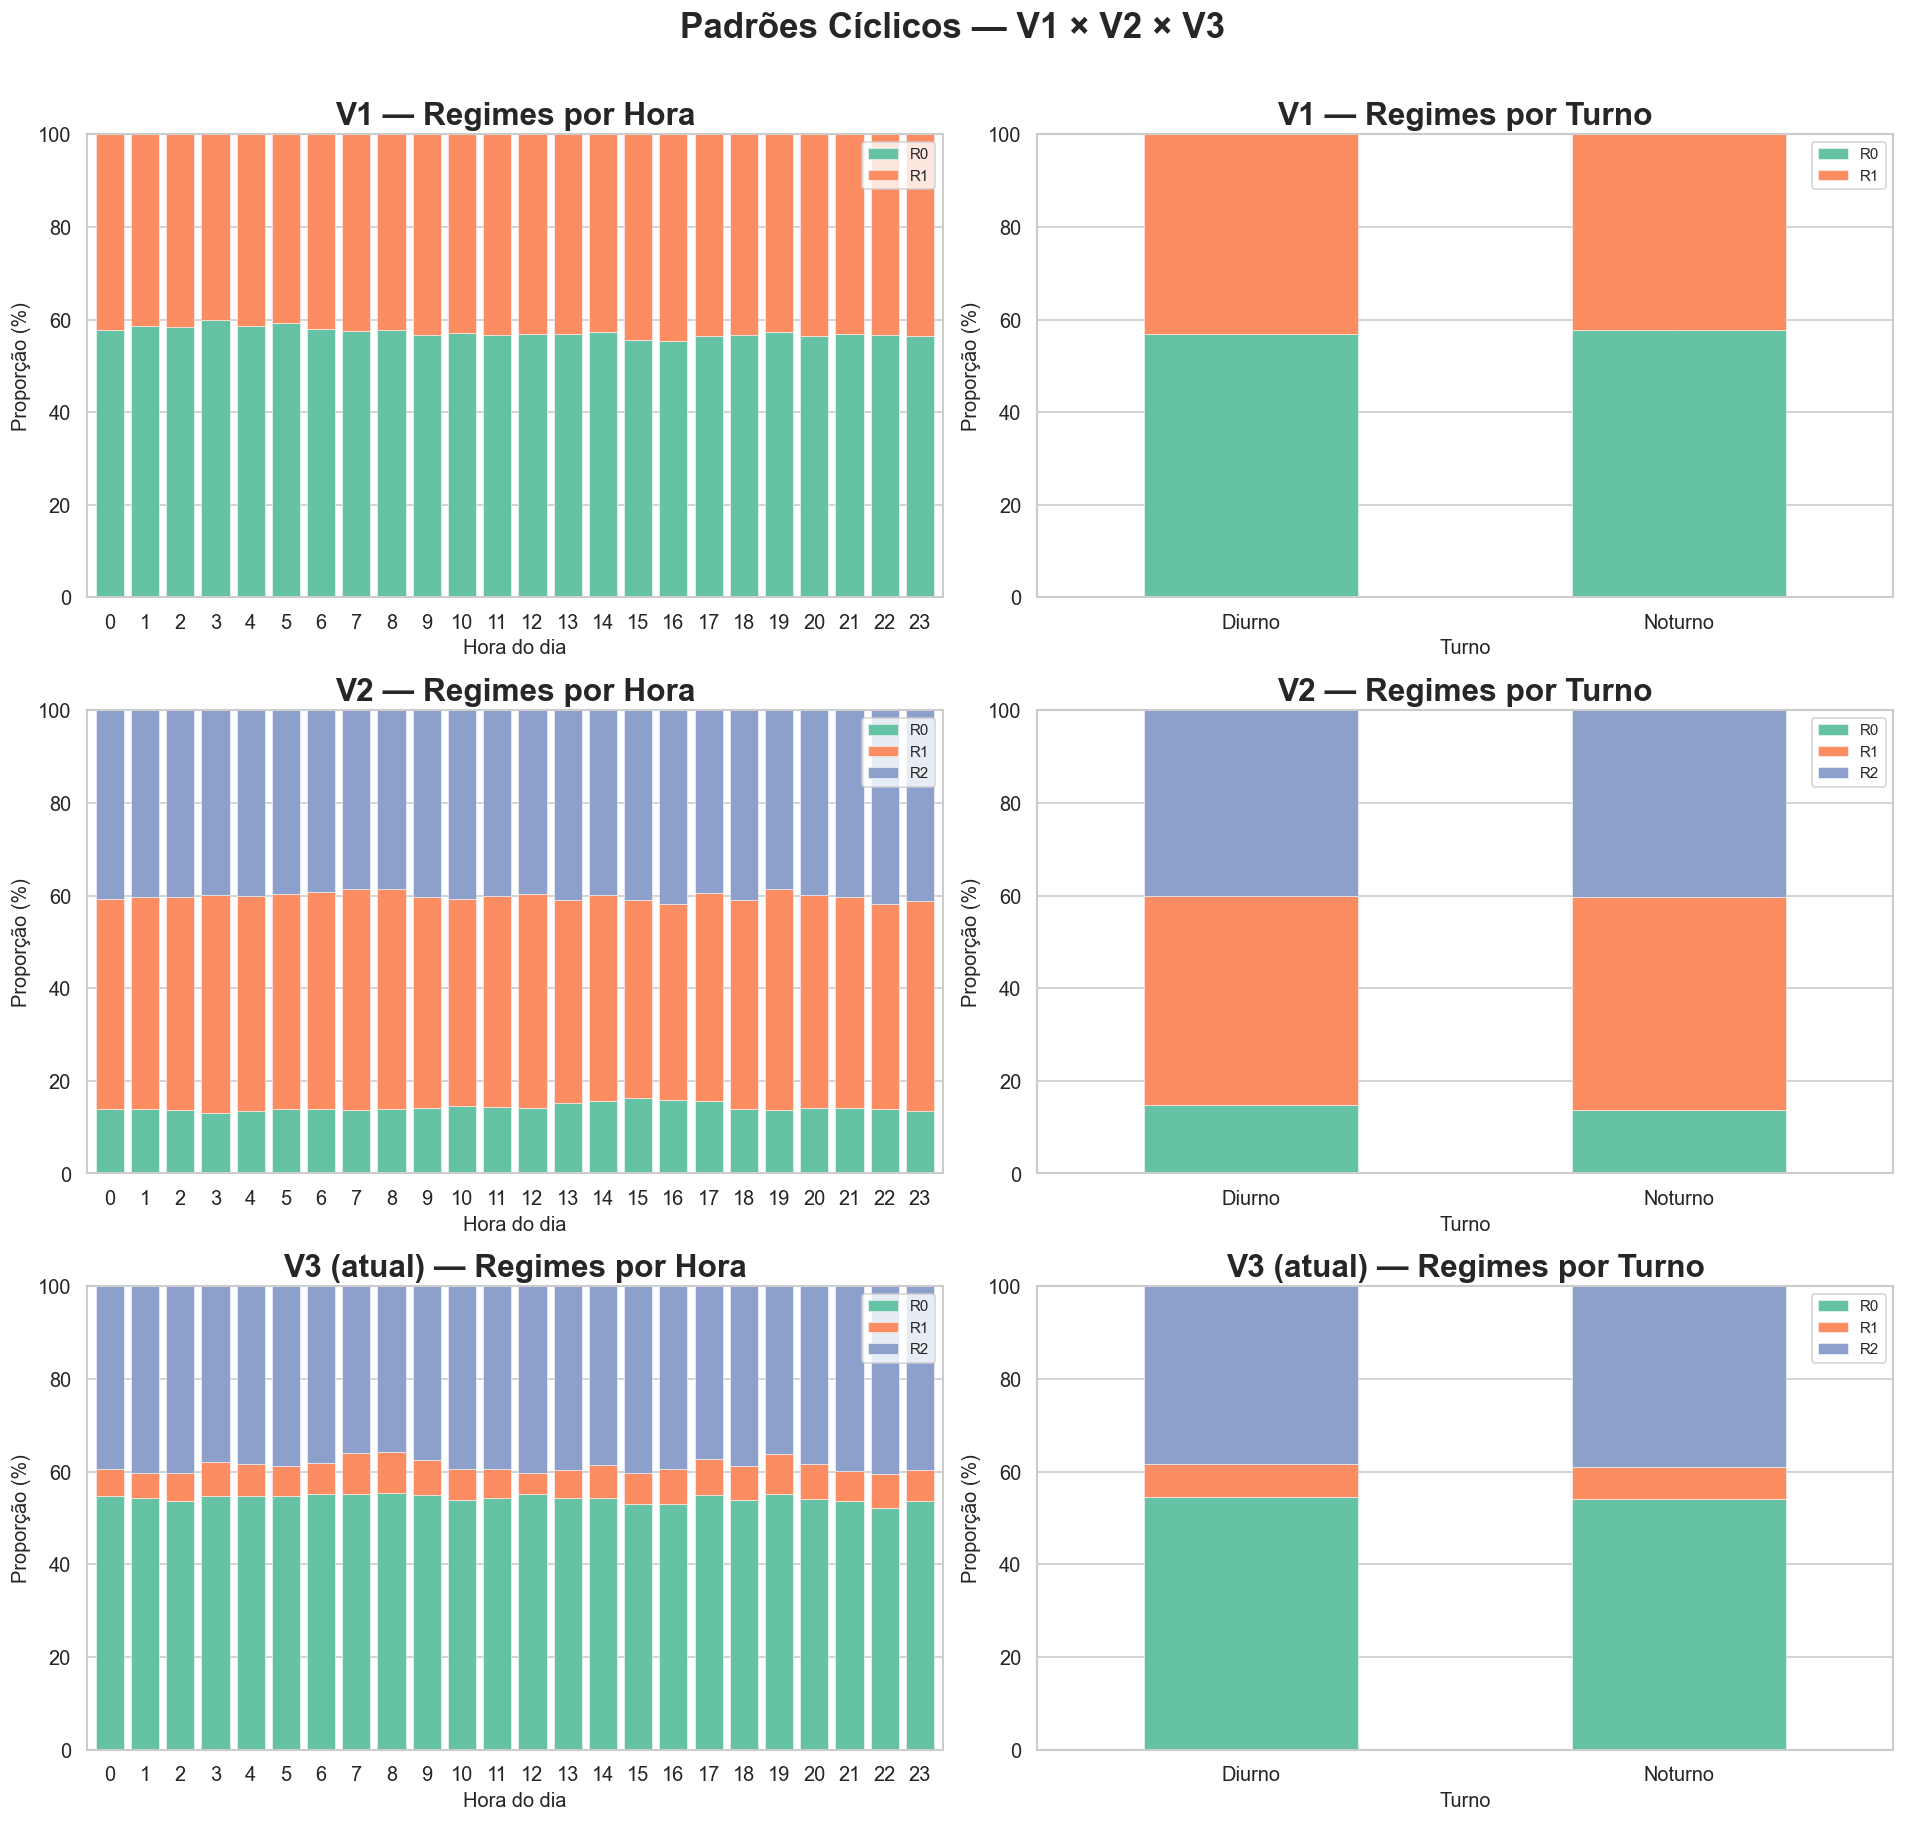


V1 — Proporção por turno (%):
regime      0     1
turno              
Diurno   56.9  43.1
Noturno  57.8  42.2

V2 — Proporção por turno (%):
regime      0     1     2
turno                    
Diurno   14.7  45.3  40.0
Noturno  13.8  45.9  40.3

V3 (atual) — Proporção por turno (%):
regime      0    1     2
turno                   
Diurno   54.5  7.0  38.4
Noturno  54.1  6.8  39.1


In [7]:
fig, axes = plt.subplots(len(VERSOES), 2, figsize=(16, 5 * len(VERSOES)))

dias_pt = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

for row, ver in enumerate(VERSOES):
    dv = datasets[ver]
    regimes_sorted = sorted(dv["regime"].unique())
    n_reg = len(regimes_sorted)

    # 5a. Proporção de regime por hora do dia
    ax = axes[row, 0]
    hora_regime = dv.groupby(["hora", "regime"]).size().unstack(fill_value=0)
    hora_pct = hora_regime.div(hora_regime.sum(axis=1), axis=0) * 100
    hora_pct.plot(kind="bar", stacked=True,
                  color=[REGIME_COLORS[r] for r in hora_pct.columns],
                  ax=ax, width=0.8, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("Proporção (%)")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Regimes por Hora", fontweight="bold")
    ax.legend([f"R{r}" for r in hora_pct.columns], fontsize=9, loc="upper right")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

    # 5b. Proporção por turno (Diurno vs Noturno)
    ax = axes[row, 1]
    turno_regime = dv.groupby(["turno", "regime"]).size().unstack(fill_value=0)
    turno_pct = turno_regime.div(turno_regime.sum(axis=1), axis=0) * 100
    turno_pct.plot(kind="bar", stacked=True,
                   color=[REGIME_COLORS[r] for r in turno_pct.columns],
                   ax=ax, width=0.5, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Turno")
    ax.set_ylabel("Proporção (%)")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Regimes por Turno", fontweight="bold")
    ax.legend([f"R{r}" for r in turno_pct.columns], fontsize=9)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Padrões Cíclicos — V1 × V2 × V3", fontsize=21, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1e_03_padroes_ciclicos.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "padroes_ciclicos", fig, "S1e_03_padroes_ciclicos.png")
plt.show()

# Imprimir proporções por turno
for ver in VERSOES:
    dv = datasets[ver]
    turno_regime = dv.groupby(["turno", "regime"]).size().unstack(fill_value=0)
    turno_pct = turno_regime.div(turno_regime.sum(axis=1), axis=0) * 100
    print(f"\n{VERSAO_LABELS[ver]} — Proporção por turno (%):")
    print(turno_pct.round(1).to_string())

## 6. Estabilidade Temporal — Evolução Mensal (V1 × V2 × V3)

**Objetivo:** Verificar se a distribuição dos regimes é estável ao longo dos meses ou se muda drasticamente — o que indicaria sensibilidade a fatores sazonais, mudanças de minério ou drift do modelo.

**Gráficos à esquerda (proporção mensal empilhada):** Mostram como a composição de regimes varia mês a mês.
- **Proporções estáveis** → os regimes capturam estados operacionais consistentes
- **Mudanças bruscas em um mês específico** → pode indicar evento operacional real (manutenção, troca de minério) ou instabilidade do modelo
- **Tendência gradual** → pode indicar drift (degradação do equipamento, mudança de blend de minério)

**Gráficos à direita (taxa de transição por mês):** Número de transições entre regimes por hora operada. A linha vermelha tracejada é a média.
- **Meses acima da média** = períodos mais instáveis (mais trocas de regime por hora)
- **Meses abaixo da média** = períodos mais estáveis
- **Picos isolados** podem coincidir com paradas de manutenção, trocas de minério ou eventos operacionais atípicos

[db_utils] Imagem 'evolucao_mensal' salva para etapa s1e


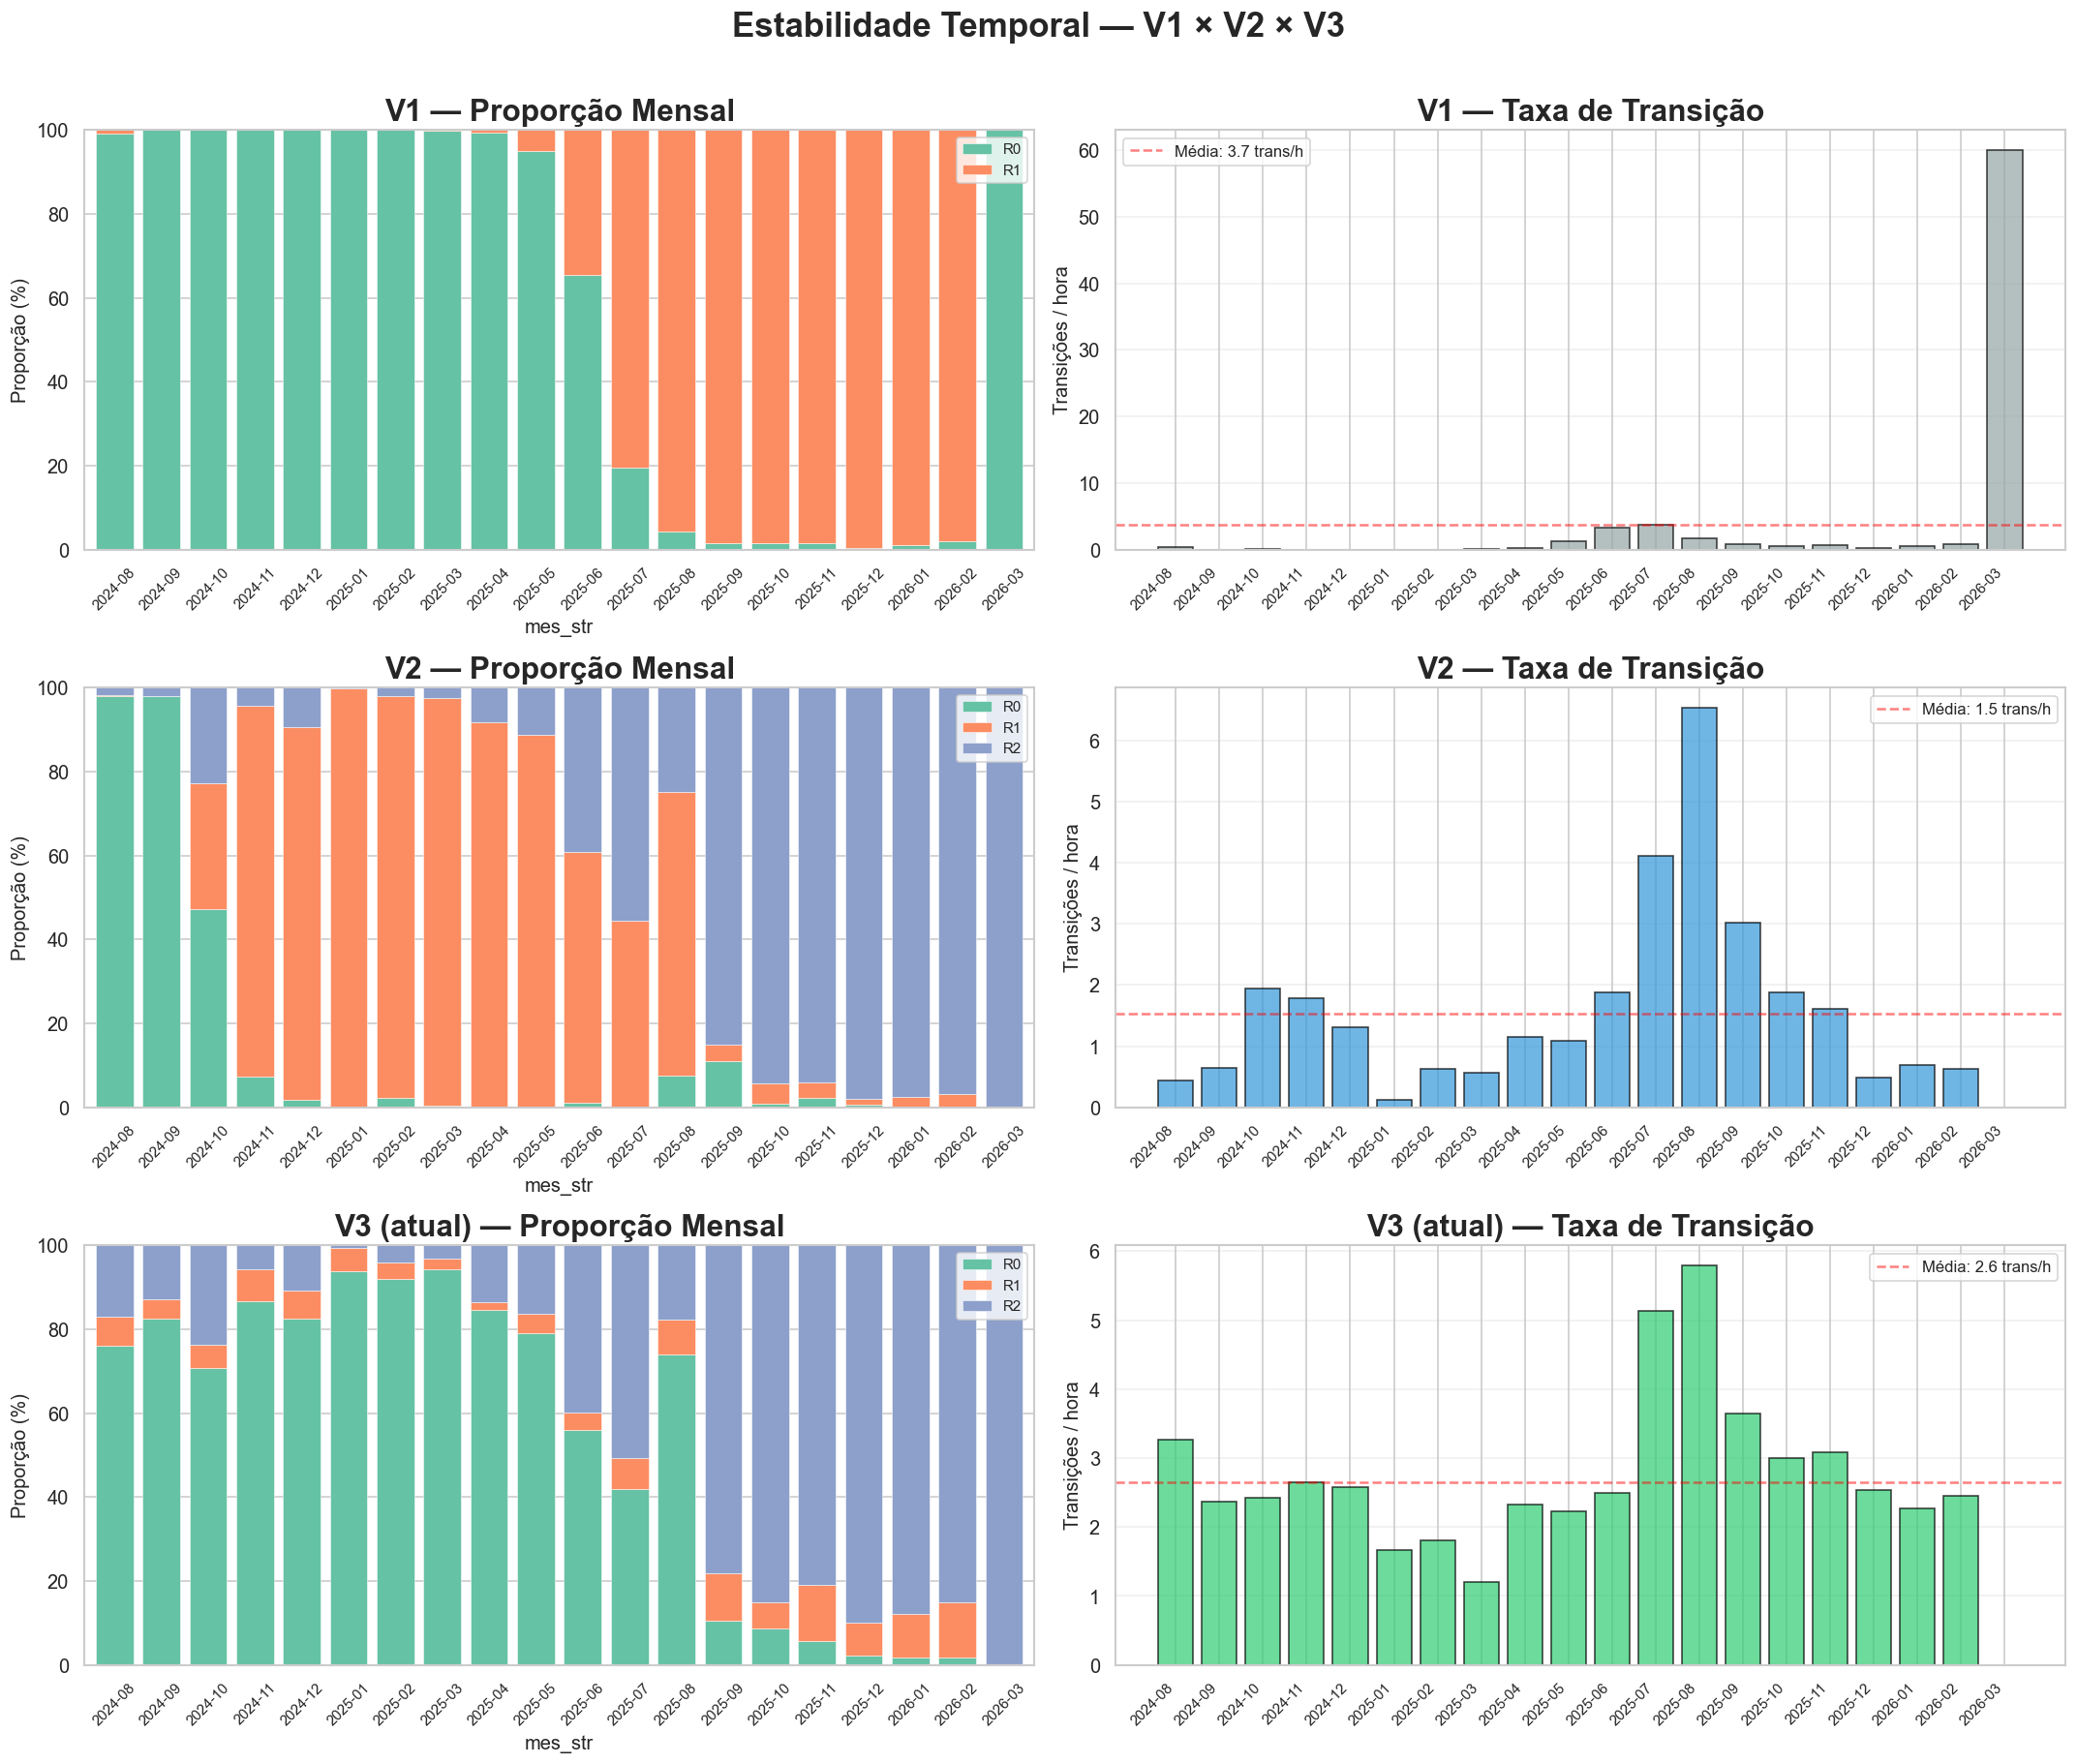


V1: média=3.7 trans/h | mais estável: 2024-12 (0.0) | 

V2: média=1.5 trans/h | mais estável: 2026-03 (0.0) | 

V3 (atual): média=2.6 trans/h | mais estável: 2026-03 (0.0) | 


In [8]:
# Proporção mensal + taxa de transição para cada versão
# Nota: coluna "transicao" já foi criada na célula de carga
mensal_pct_por_versao = {}
taxa_trans_por_versao = {}

for ver in VERSOES:
    dv = datasets[ver]
    dv["mes_str"] = dv.index.to_period("M").astype(str)
    mensal = dv.groupby(["mes_str", "regime"]).size().unstack(fill_value=0)
    mensal_pct = mensal.div(mensal.sum(axis=1), axis=0) * 100
    mensal_pct_por_versao[ver] = mensal_pct

    trans_mensal = dv.groupby("mes_str")["transicao"].sum()
    horas_mensal = dv.groupby("mes_str").size() / 60
    taxa_trans_por_versao[ver] = (trans_mensal / horas_mensal).replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(len(VERSOES), 2, figsize=(18, 5 * len(VERSOES)), squeeze=False)

for row, ver in enumerate(VERSOES):
    mensal_pct = mensal_pct_por_versao[ver]
    taxa_trans = taxa_trans_por_versao[ver]

    # Proporção mensal empilhada
    ax = axes[row, 0]
    mensal_pct.plot(kind="bar", stacked=True,
                    color=[REGIME_COLORS[r] for r in mensal_pct.columns],
                    ax=ax, width=0.8, edgecolor="white", linewidth=0.3)
    ax.set_ylabel("Proporção (%)")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Proporção Mensal", fontweight="bold")
    ax.legend([f"R{r}" for r in mensal_pct.columns], fontsize=9, loc="upper right")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45, labelsize=9)

    # Taxa de transição mensal
    ax = axes[row, 1]
    ax.bar(range(len(taxa_trans)), taxa_trans.values, color=VERSAO_COLORS[ver], alpha=0.7, edgecolor="black")
    ax.set_xticks(range(len(taxa_trans)))
    ax.set_xticklabels(taxa_trans.index, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Transições / hora")
    ax.set_title(f"{VERSAO_LABELS[ver]} — Taxa de Transição", fontweight="bold")
    ax.axhline(taxa_trans.mean(), color="red", linestyle="--", alpha=0.5,
               label=f"Média: {taxa_trans.mean():.1f} trans/h")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Estabilidade Temporal — V1 × V2 × V3", fontsize=21, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1e_04_evolucao_mensal.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "evolucao_mensal", fig, "S1e_04_evolucao_mensal.png")
plt.show()

for ver in VERSOES:
    tt = taxa_trans_por_versao[ver]
    print(f"\n{VERSAO_LABELS[ver]}: média={tt.mean():.1f} trans/h | "
          f"mais estável: {tt.idxmin()} ({tt.min():.1f}) | " if len(tt) > 0 else "sem dados | "
          f"mais instável: {tt.idxmax()} ({tt.max():.1f})" if len(tt) > 0 else "sem dados")

## 7. Impacto Energético das Transições (V1 × V2 × V3)

**Por que analisar energia?** Transições entre regimes não são apenas mudanças de rótulo — elas representam momentos em que o processo está se ajustando, potencialmente com perda de eficiência. Se os regimes são reais, esperamos que os períodos de transição tenham **energia específica (kWh/t) diferente** dos períodos estáveis.

**Definição de "período de transição":** Janela de ±15 minutos ao redor de cada mudança de regime. O restante é classificado como "estável".

**Gráficos da esquerda (boxplot Estável vs Transição):**
- Se a mediana de transição é **maior** que a de estável → transições gastam mais energia por tonelada (ineficiência durante ajuste)
- Se são **iguais** → transições não impactam energeticamente (ou o modelo não captura o fenômeno)
- O valor **delta** (diferença das medianas) quantifica o custo energético das transições

**Gráficos do centro (energia por regime e período):** Barras sólidas = estável, barras hachuradas = transição, para cada regime. Permite ver qual regime é mais impactado pelas transições.

**Gráficos da direita (TPH por regime e período):** Mesma lógica aplicada à vazão (toneladas por hora). Quedas de TPH durante transição indicam perda de produtividade.

> **Atenção ao "% tempo em transição":** Se esse percentual for muito alto (>30%), significa que a versão do clustering tem tantas transições que a planta passa boa parte do tempo "em ajuste" — sinal de regime fragmentado, não de instabilidade real do processo.

[db_utils] Imagem 'impacto_energetico' salva para etapa s1e


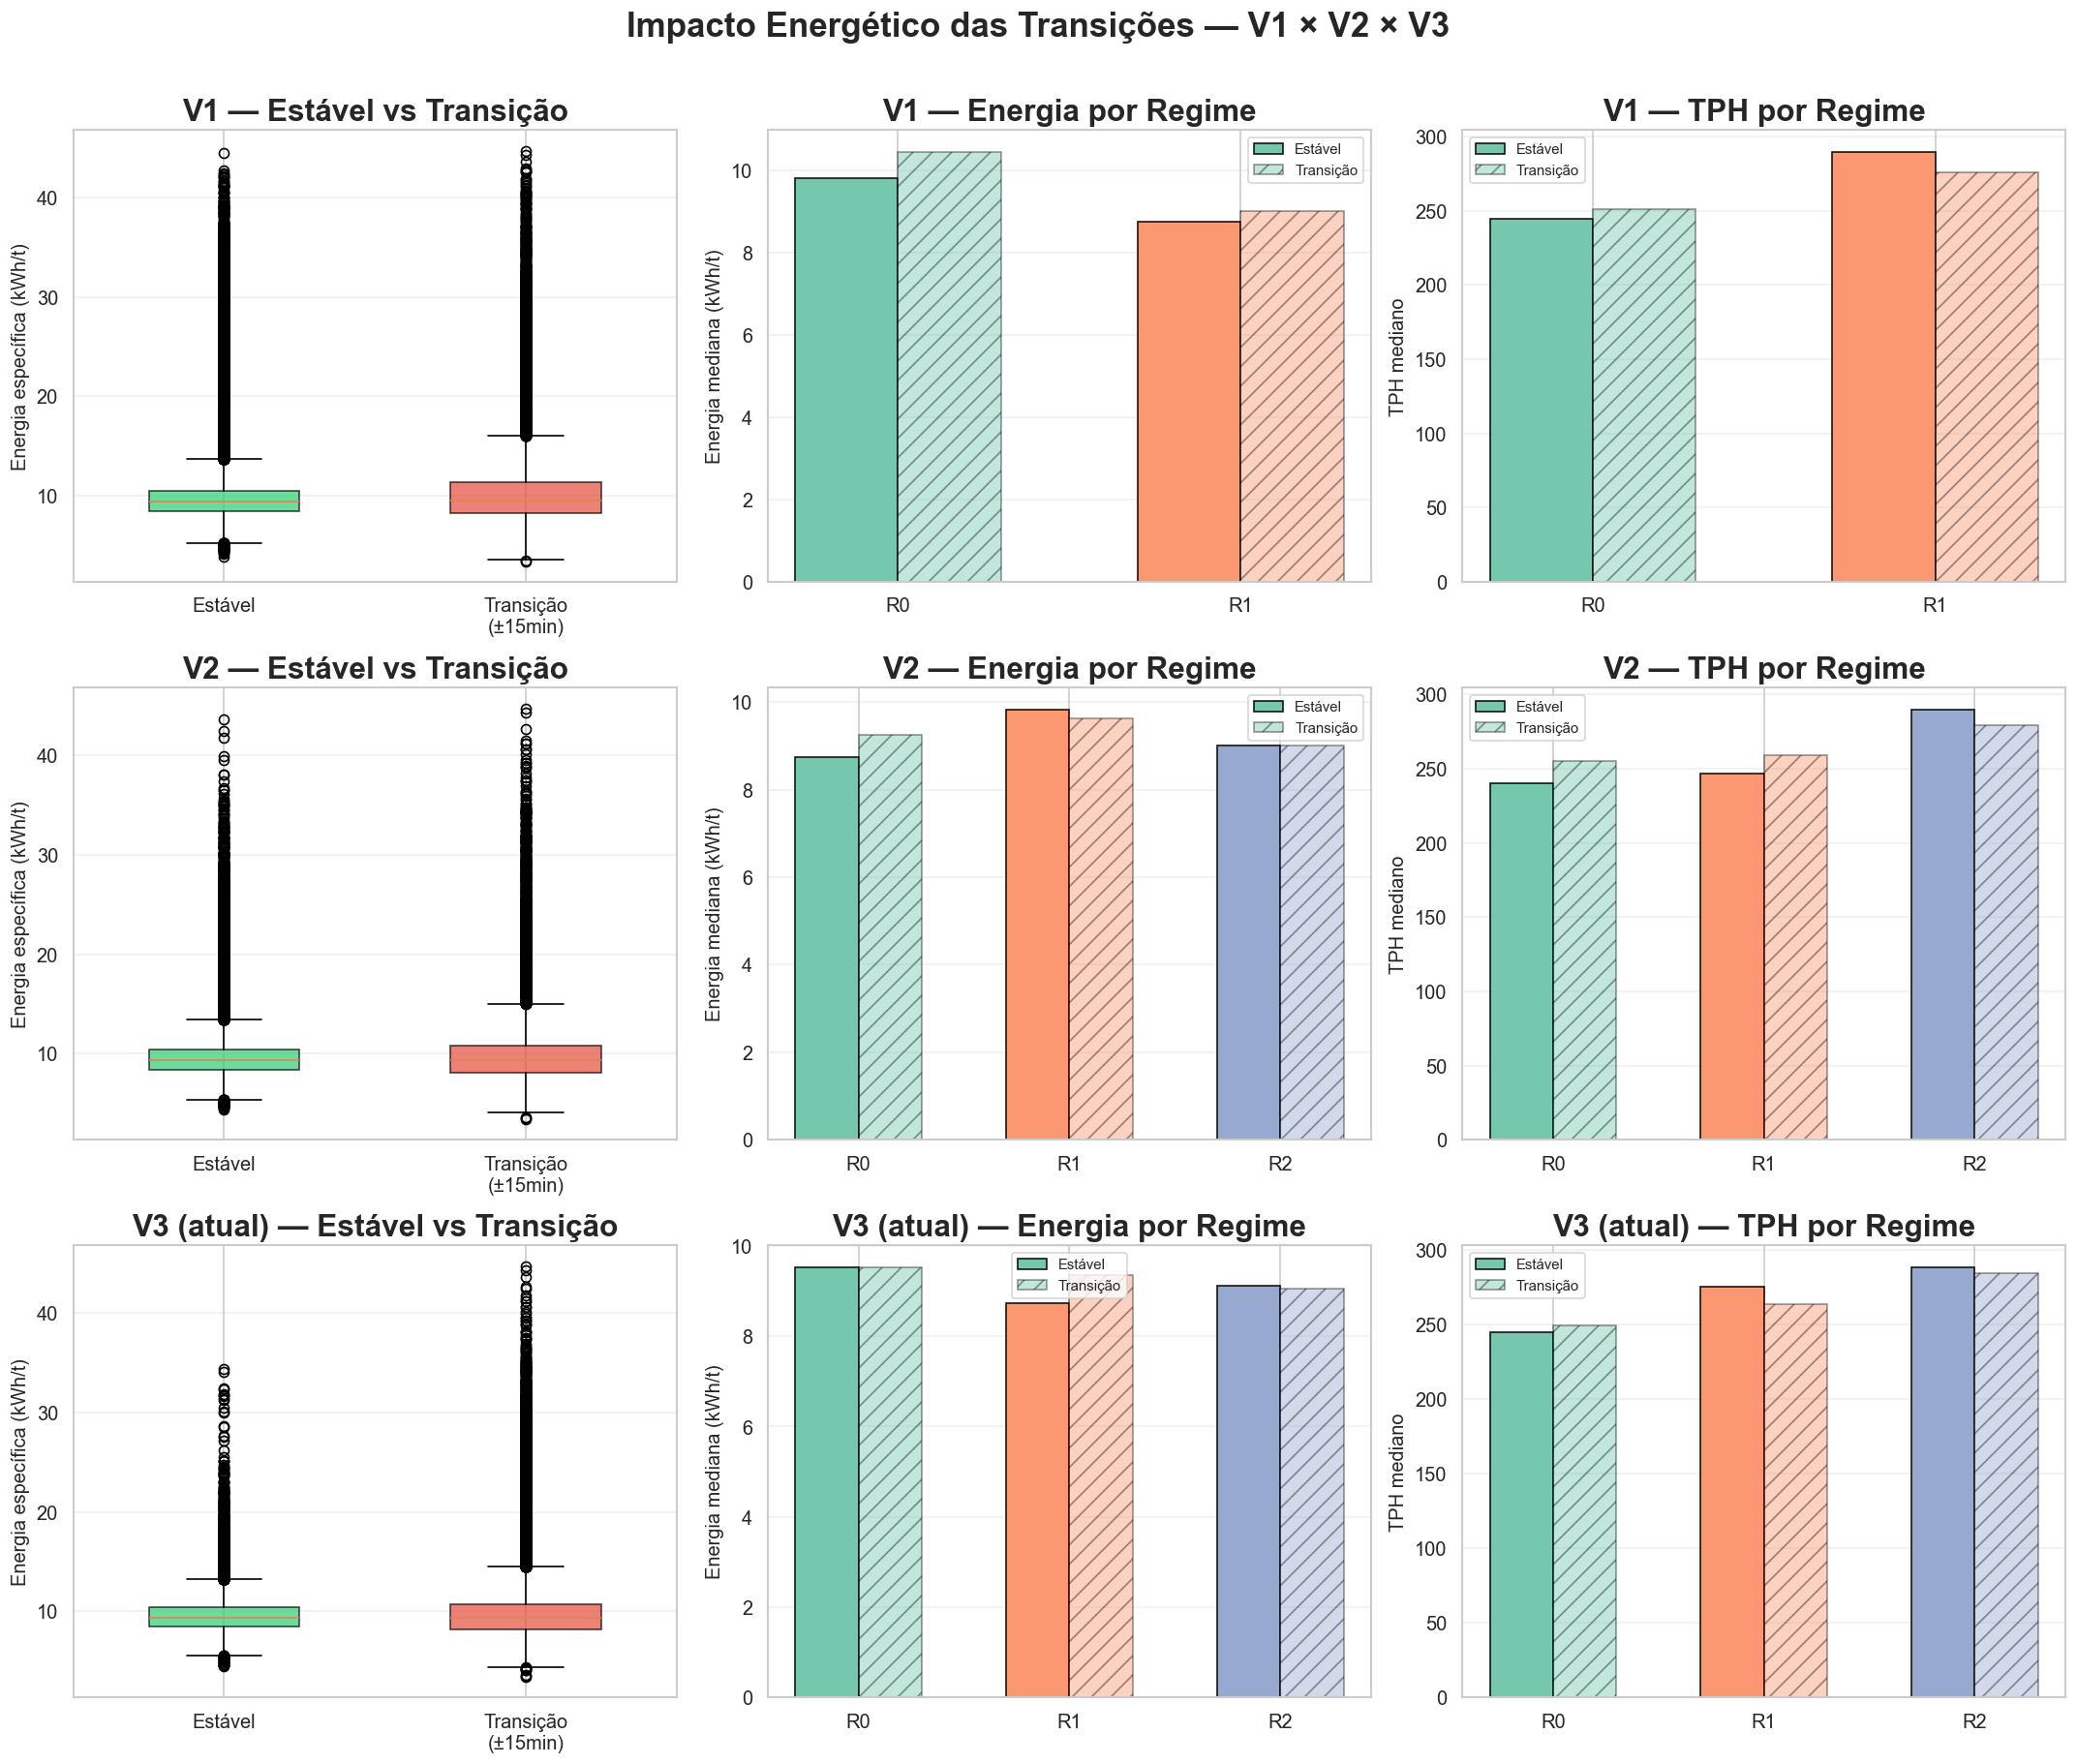

V1: delta=+0.165 kWh/t (+1.8%) | tempo em transição: 9.1%
V2: delta=-0.053 kWh/t (-0.6%) | tempo em transição: 15.7%
V3 (atual): delta=-0.072 kWh/t (-0.8%) | tempo em transição: 36.8%


In [9]:
# Impacto energético: comparar estável vs transição para cada versão
JANELA_TRANSICAO = 15  # minutos

energia_por_versao = {}

for ver in VERSOES:
    dv = datasets[ver]

    # Marcar janela de transição (±15 min ao redor de cada mudança)
    idx_transicao = np.where(dv["transicao"] == 1)[0]
    mask_transicao = np.zeros(len(dv), dtype=bool)
    for idx in idx_transicao:
        start = max(0, idx - JANELA_TRANSICAO)
        end = min(len(dv), idx + JANELA_TRANSICAO + 1)
        mask_transicao[start:end] = True
    dv["periodo"] = np.where(mask_transicao, "Transição (±15min)", "Estável")

    # Energia específica — usar FEAT_ se existir, senão calcular on-the-fly
    col_energia = None
    if "FEAT_energia_especifica" in dv.columns:
        col_energia = "FEAT_energia_especifica"
    elif col_pot is not None and col_pot in dv.columns:
        col_energia = "energia_especifica_calc"
        tph_vals = dv[col_tph]
        pot_vals = dv[col_pot]
        dv[col_energia] = np.where(tph_vals > 50, pot_vals / tph_vals, np.nan)

    energia_por_versao[ver] = {
        "col_energia": col_energia,
        "mask_transicao": mask_transicao,
    }

# Plotar apenas se energia disponível
has_energia = any(e["col_energia"] is not None for e in energia_por_versao.values())

if has_energia:
    fig, axes = plt.subplots(len(VERSOES), 3, figsize=(18, 5 * len(VERSOES)))

    for row, ver in enumerate(VERSOES):
        dv = datasets[ver]
        col_energia = energia_por_versao[ver]["col_energia"]
        mask_transicao = energia_por_versao[ver]["mask_transicao"]
        regimes_sorted = sorted(dv["regime"].unique())
        n_reg = len(regimes_sorted)

        if col_energia is None:
            for c in range(3):
                axes[row, c].text(0.5, 0.5, "Sem dados de energia",
                                  transform=axes[row, c].transAxes, ha="center")
                axes[row, c].set_title(f"{VERSAO_LABELS[ver]}", fontweight="bold")
            continue

        # 7a. Boxplot: energia por período
        ax = axes[row, 0]
        data_est = dv[dv["periodo"] == "Estável"][col_energia].dropna()
        data_trans = dv[dv["periodo"] == "Transição (±15min)"][col_energia].dropna()
        bp = ax.boxplot([data_est, data_trans],
                        labels=["Estável", "Transição\n(±15min)"],
                        patch_artist=True, widths=0.5)
        bp["boxes"][0].set_facecolor("#2ecc71")
        bp["boxes"][1].set_facecolor("#e74c3c")
        for b in bp["boxes"]:
            b.set_alpha(0.7)
        ax.set_ylabel("Energia específica (kWh/t)")
        ax.set_title(f"{VERSAO_LABELS[ver]} — Estável vs Transição", fontweight="bold")
        ax.grid(True, alpha=0.3, axis="y")

        delta = data_trans.median() - data_est.median()
        energia_por_versao[ver]["delta"] = delta
        energia_por_versao[ver]["mediana_est"] = data_est.median()
        energia_por_versao[ver]["pct_transicao"] = 100 * mask_transicao.sum() / len(dv)

        # 7b. Energia por regime e período
        ax = axes[row, 1]
        for i, r in enumerate(regimes_sorted):
            est = dv[(dv["regime"] == r) & (dv["periodo"] == "Estável")][col_energia].median()
            trans = dv[(dv["regime"] == r) & (dv["periodo"] == "Transição (±15min)")][col_energia].median()
            ax.bar(i - 0.15, est if pd.notna(est) else 0, width=0.3,
                   color=REGIME_COLORS[r], alpha=0.9, edgecolor="black",
                   label="Estável" if i == 0 else "")
            ax.bar(i + 0.15, trans if pd.notna(trans) else 0, width=0.3,
                   color=REGIME_COLORS[r], alpha=0.4, edgecolor="black",
                   hatch="//", label="Transição" if i == 0 else "")
        ax.set_xticks(range(n_reg))
        ax.set_xticklabels([f"R{r}" for r in regimes_sorted])
        ax.set_ylabel("Energia mediana (kWh/t)")
        ax.set_title(f"{VERSAO_LABELS[ver]} — Energia por Regime", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis="y")

        # 7c. TPH por regime e período
        ax = axes[row, 2]
        for i, r in enumerate(regimes_sorted):
            est = dv[(dv["regime"] == r) & (dv["periodo"] == "Estável")][col_tph].median()
            trans = dv[(dv["regime"] == r) & (dv["periodo"] == "Transição (±15min)")][col_tph].median()
            ax.bar(i - 0.15, est if pd.notna(est) else 0, width=0.3,
                   color=REGIME_COLORS[r], alpha=0.9, edgecolor="black",
                   label="Estável" if i == 0 else "")
            ax.bar(i + 0.15, trans if pd.notna(trans) else 0, width=0.3,
                   color=REGIME_COLORS[r], alpha=0.4, edgecolor="black",
                   hatch="//", label="Transição" if i == 0 else "")
        ax.set_xticks(range(n_reg))
        ax.set_xticklabels([f"R{r}" for r in regimes_sorted])
        ax.set_ylabel("TPH mediano")
        ax.set_title(f"{VERSAO_LABELS[ver]} — TPH por Regime", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle("Impacto Energético das Transições — V1 × V2 × V3", fontsize=21, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "S1e_05_impacto_energetico.png", dpi=150, bbox_inches="tight")
    salvar_imagem(STAGE, "impacto_energetico", fig, "S1e_05_impacto_energetico.png")
    plt.show()

    for ver in VERSOES:
        info = energia_por_versao[ver]
        if "delta" in info:
            print(f"{VERSAO_LABELS[ver]}: delta={info['delta']:+.3f} kWh/t "
                  f"({100*info['delta']/info['mediana_est']:+.1f}%) | "
                  f"tempo em transição: {info['pct_transicao']:.1f}%")
else:
    print("Coluna de potência não encontrada — análise energética não disponível.")

## 8. Série Temporal Detalhada — Zoom em Semanas Típicas (V1 × V2 × V3)

**Objetivo:** Visualizar como os regimes se comportam minuto a minuto em duas semanas contrastantes — a mais **estável** e a mais **instável** do período, selecionadas com base na V3 (versão atual).

**Como ler os gráficos:**
- **Pontos coloridos** = regime atribuído a cada minuto (eixo Y = número do regime)
- **Linha cinza** (eixo Y secundário) = TPH (vazão), para dar contexto operacional
- **Linha superior: semana estável** → poucos blocos longos, poucas mudanças de cor
- **Linha inferior: semana instável** → muitas alternâncias rápidas de cor

**O que observar ao comparar V1, V2 e V3:**
- **V1** (2 regimes): espera-se blocos mais longos (menos opções de classificação), mas pode perder nuances
- **V2** (3 regimes): intermediário — deve capturar mais estados sem fragmentar excessivamente
- **V3** (3 regimes): se fragmentar mais que V2 (muita alternância rápida), pode indicar que as features engenheiradas introduziram ruído temporal

> **Teste visual rápido:** Na semana estável, a V3 deveria mostrar blocos longos e coerentes. Na semana instável, alguma fragmentação é esperada — mas se parecer "ruído branco" (alternância aleatória a cada minuto), o modelo não está capturando estados reais.

[db_utils] Imagem 'zoom_semanas' salva para etapa s1e


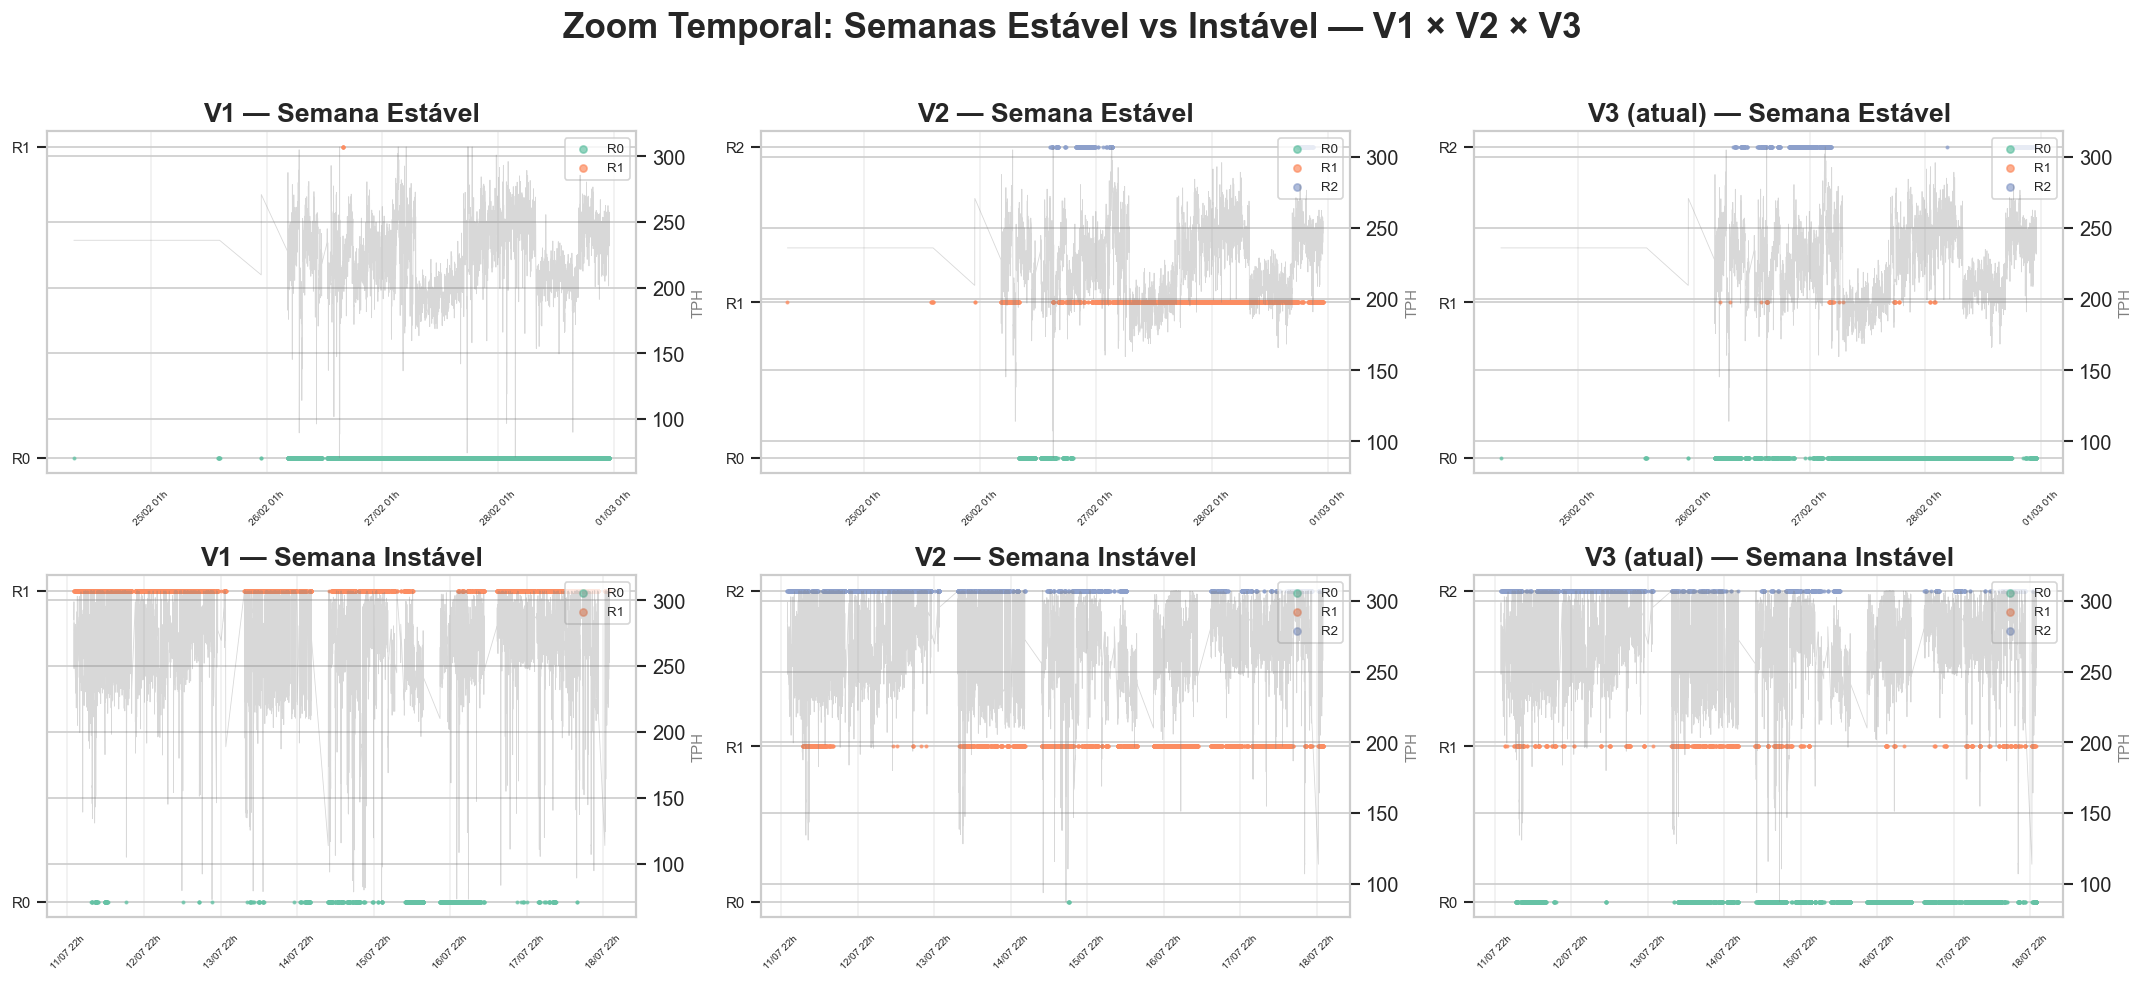

Semana estável: 22/02/2025 — 5 trans/dia (média)
Semana instável: 12/07/2025 — 131 trans/dia (média)


In [10]:
# Selecionar semanas representativas com base na V3 e mostrar as 3 versões no mesmo período
df_ref = datasets["v3"]
df_ref["data"] = df_ref.index.date
trans_diaria = df_ref.groupby("data")["transicao"].sum()
trans_semanal = trans_diaria.rolling(7).mean().dropna()

if len(trans_semanal) == 0:
    raise RuntimeError("Dados insuficientes para calcular rolling semanal (menos de 7 dias).")

dia_estavel = trans_semanal.idxmin()
inicio_estavel = pd.Timestamp(dia_estavel) - pd.Timedelta(days=3)
fim_estavel = inicio_estavel + pd.Timedelta(days=7)

dia_instavel = trans_semanal.idxmax()
inicio_instavel = pd.Timestamp(dia_instavel) - pd.Timedelta(days=3)
fim_instavel = inicio_instavel + pd.Timedelta(days=7)

fig, axes = plt.subplots(2, len(VERSOES), figsize=(6 * len(VERSOES), 8), squeeze=False)

for col_idx, ver in enumerate(VERSOES):
    dv = datasets[ver]
    regimes_sorted = sorted(dv["regime"].unique())

    for row_idx, (inicio, fim, titulo_tipo) in enumerate([
        (inicio_estavel, fim_estavel, "Estável"),
        (inicio_instavel, fim_instavel, "Instável"),
    ]):
        ax = axes[row_idx, col_idx]
        mask = (dv.index >= inicio) & (dv.index < fim)
        sub = dv[mask]
        if len(sub) == 0:
            ax.text(0.5, 0.5, "Sem dados", transform=ax.transAxes, ha="center")
            continue

        # TPH como linha cinza
        ax2 = ax.twinx()
        if col_tph in sub.columns:
            ax2.plot(sub.index, sub[col_tph], color="gray", alpha=0.3, linewidth=0.5)
            ax2.set_ylabel("TPH", color="gray", fontsize=9)

        # Regime como scatter colorido
        for r in regimes_sorted:
            m = sub["regime"] == r
            ax.scatter(sub.index[m], sub["regime"][m], c=REGIME_COLORS[r], s=2, alpha=0.7,
                       label=f"R{r}")

        ax.set_yticks(regimes_sorted)
        ax.set_yticklabels([f"R{r}" for r in regimes_sorted], fontsize=9)
        ax.set_title(f"{VERSAO_LABELS[ver]} — Semana {titulo_tipo}", fontweight="bold", fontsize=16)
        ax.legend(fontsize=8, loc="upper right", markerscale=3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, fontsize=6)
        ax.grid(True, alpha=0.3, axis="x")

fig.suptitle("Zoom Temporal: Semanas Estável vs Instável — V1 × V2 × V3",
             fontsize=21, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "S1e_06_zoom_semanas.png", dpi=150, bbox_inches="tight")
salvar_imagem(STAGE, "zoom_semanas", fig, "S1e_06_zoom_semanas.png")
plt.show()

print(f"Semana estável: {inicio_estavel.strftime('%d/%m/%Y')} — {trans_semanal[dia_estavel]:.0f} trans/dia (média)")
print(f"Semana instável: {inicio_instavel.strftime('%d/%m/%Y')} — {trans_semanal[dia_instavel]:.0f} trans/dia (média)")

## 9. Salvamento dos Resultados (por versão)

In [11]:
# Salvar resultados por versão (local + PostgreSQL)
print("Salvando resultados por versão...")

for ver in VERSOES:
    label = VERSAO_LABELS[ver]
    blocos = blocos_por_versao[ver]
    stats = stats_permanencia_por_versao[ver]
    tm = trans_matrices[ver]
    mensal_pct = mensal_pct_por_versao[ver]
    taxa_trans = taxa_trans_por_versao[ver]
    suffix = f"_{ver}"  # _v1, _v2, _v3

    # === CSVs locais ===
    stats.to_csv(DATA_PROC / f"s1e_temporal_permanencia{suffix}.csv", index=False)
    tm["prob"].to_csv(DATA_PROC / f"s1e_temporal_transicao{suffix}.csv")
    mensal_pct.to_csv(DATA_PROC / f"s1e_temporal_mensal{suffix}.csv")
    taxa_trans.to_csv(DATA_PROC / f"s1e_temporal_taxa_transicao{suffix}.csv")
    blocos.to_csv(DATA_PROC / f"s1e_temporal_blocos{suffix}.csv", index=False)

    # === PostgreSQL (modo="replace" para criar tabelas na primeira execução) ===
    # 1. Permanência
    stats_db = stats.copy()
    stats_db["versao"] = ver
    salvar_dataframe(stats_db, f"s1e_{ver}_permanencia_regimes", modo="replace")

    # 2. Matriz de transição (melted)
    df_prob_m = tm["prob"].reset_index().melt(
        id_vars="index", var_name="regime_para", value_name="probabilidade")
    df_prob_m.rename(columns={"index": "regime_de"}, inplace=True)
    df_count_m = tm["count"].reset_index().melt(
        id_vars="index", var_name="regime_para", value_name="contagem")
    df_count_m.rename(columns={"index": "regime_de"}, inplace=True)
    df_trans_m = df_prob_m.copy()
    df_trans_m["contagem"] = df_count_m["contagem"]
    df_trans_m["versao"] = ver
    salvar_dataframe(df_trans_m, f"s1e_{ver}_matriz_transicao", modo="replace")

    # 3. Distribuição mensal (melted)
    df_mensal_m = mensal_pct.reset_index().melt(
        id_vars="mes_str", var_name="regime", value_name="percentual")
    df_mensal_m.rename(columns={"mes_str": "mes"}, inplace=True)
    df_mensal_m["versao"] = ver
    salvar_dataframe(df_mensal_m, f"s1e_{ver}_distribuicao_mensal", modo="replace")

    # 4. Taxa de transição mensal
    df_taxa = pd.DataFrame({"mes": taxa_trans.index, "transicoes_hora": taxa_trans.values})
    df_taxa["versao"] = ver
    salvar_dataframe(df_taxa, f"s1e_{ver}_taxa_transicao", modo="replace")

    # 5. Blocos
    blocos_db = blocos[["bloco_id", "regime", "inicio", "fim", "duracao_min", "duracao_h"]].copy()
    blocos_db["versao"] = ver
    salvar_dataframe(blocos_db, f"s1e_{ver}_blocos_regime", modo="replace")

    print(f"  {label}: 5 CSVs + 5 tabelas PostgreSQL")

print("\nDados temporais salvos para V1, V2 e V3.")

Salvando resultados por versão...
[db_utils] 2 linhas salvas em otimizar_moagem_aura.s1e_v1_permanencia_regimes
[db_utils] 4 linhas salvas em otimizar_moagem_aura.s1e_v1_matriz_transicao
[db_utils] 40 linhas salvas em otimizar_moagem_aura.s1e_v1_distribuicao_mensal
[db_utils] 20 linhas salvas em otimizar_moagem_aura.s1e_v1_taxa_transicao
[db_utils] 7,773 linhas salvas em otimizar_moagem_aura.s1e_v1_blocos_regime
  V1: 5 CSVs + 5 tabelas PostgreSQL
[db_utils] 3 linhas salvas em otimizar_moagem_aura.s1e_v2_permanencia_regimes
[db_utils] 9 linhas salvas em otimizar_moagem_aura.s1e_v2_matriz_transicao
[db_utils] 60 linhas salvas em otimizar_moagem_aura.s1e_v2_distribuicao_mensal
[db_utils] 20 linhas salvas em otimizar_moagem_aura.s1e_v2_taxa_transicao
[db_utils] 15,915 linhas salvas em otimizar_moagem_aura.s1e_v2_blocos_regime
  V2: 5 CSVs + 5 tabelas PostgreSQL
[db_utils] 3 linhas salvas em otimizar_moagem_aura.s1e_v3_permanencia_regimes
[db_utils] 9 linhas salvas em otimizar_moagem_aura.

## 10. Resumo Comparativo — V1 × V2 × V3

**Tabela final** com as métricas-chave de cada versão lado a lado. Use esta seção para decidir qual versão do clustering produz regimes mais coerentes temporalmente.

**Guia de leitura da tabela:**

| Métrica | Melhor quando... | Por quê |
|---|---|---|
| **Blocos** | Menor número | Menos fragmentação — blocos mais longos |
| **Taxa trans/h** | Mais baixa | Menos trocas de regime por hora = mais estabilidade |
| **Duração média** | Mais alta | Regime se sustenta por mais tempo |
| **Auto-transição** | Mais próxima de 100% | Baixa chance de sair do regime a cada minuto |
| **Delta energia** | Diferente de zero | Transições têm impacto energético real (regimes capturaram algo) |
| **% tempo transição** | Mais baixo | Menos tempo "em ajuste" entre regimes |

> **Nota importante:** Nenhuma métrica isolada define a "melhor" versão. O ideal é equilíbrio: regimes estáveis (auto-transição alta, taxa baixa) **e** distintos operacionalmente (delta energia significativo, padrões cíclicos visíveis).

In [12]:
elapsed = time.time() - t0
print("\n" + "=" * 70)
print("  RESUMO COMPARATIVO — ANÁLISE TEMPORAL (V1 × V2 × V3)")
print("=" * 70)
print(f"  Tempo total: {elapsed:.0f}s ({elapsed/60:.1f} min)")

# Tabela comparativa
rows = []
for ver in VERSOES:
    dv = datasets[ver]
    blocos = blocos_por_versao[ver]
    tm = trans_matrices[ver]
    taxa = taxa_trans_por_versao[ver]

    n_reg = dv["regime"].nunique()
    n_blocos = len(blocos)
    n_trans = n_blocos - 1
    taxa_media = taxa.mean()

    # Auto-transição média (estabilidade)
    auto_trans = np.diag(tm["prob_raw"]).mean()

    # Duração média ponderada dos blocos
    dur_media = blocos["duracao_min"].mean()

    row = {
        "Versão": VERSAO_LABELS[ver],
        "Regimes": n_reg,
        "Registros": f"{len(dv):,}",
        "Blocos": f"{n_blocos:,}",
        "Transições": f"{n_trans:,}",
        "Taxa trans/h": f"{taxa_media:.1f}",
        "Duração média (min)": f"{dur_media:.1f}",
        "Auto-transição média": f"{auto_trans*100:.1f}%",
    }

    # Energia (se disponível)
    info = energia_por_versao.get(ver, {})
    if "delta" in info:
        row["Delta energia (kWh/t)"] = f"{info['delta']:+.3f}"
        row["% tempo transição"] = f"{info['pct_transicao']:.1f}%"

    rows.append(row)

df_comparativo = pd.DataFrame(rows).set_index("Versão")
print("\n")
print(df_comparativo.to_string())

# Detalhe por versão
for ver in VERSOES:
    tm = trans_matrices[ver]
    stats = stats_permanencia_por_versao[ver]
    print(f"\n{'─' * 50} {VERSAO_LABELS[ver]} {'─' * 10}")
    print("  Permanência média por regime:")
    for _, row in stats.iterrows():
        r = int(row["regime"])
        print(f"    R{r}: {row['duracao_media_min']:.0f}min ({row['duracao_media_h']:.1f}h) | "
              f"{int(row['n_blocos']):,} blocos | "
              f"≤5min: {row['pct_blocos_curtos_5min']:.0f}% | ≥1h: {row['pct_blocos_longos_1h']:.0f}%")
    print("  Auto-transição:")
    for j, r in enumerate(tm["regimes"]):
        print(f"    R{r}: {tm['prob_raw'][j,j]*100:.2f}%")

print("\n" + "=" * 70)
print("  Figuras salvas:", len(list(FIGURES_DIR.glob("S1e_*.png"))), f"em {FIGURES_DIR}")
print("=" * 70)


  RESUMO COMPARATIVO — ANÁLISE TEMPORAL (V1 × V2 × V3)
  Tempo total: 38s (0.6 min)


            Regimes Registros  Blocos Transições Taxa trans/h Duração média (min) Auto-transição média Delta energia (kWh/t) % tempo transição
Versão                                                                                                                                        
V1                2   632,985   7,773      7,772          3.7                81.4                98.7%                +0.165              9.1%
V2                3   632,985  15,915     15,914          1.5                39.8                97.4%                -0.053             15.7%
V3 (atual)        3   632,970  28,855     28,854          2.6                21.9                91.3%                -0.072             36.8%

────────────────────────────────────────────────── V1 ──────────
  Permanência média por regime:
    R0: 93min (1.6h) | 3,887 blocos | ≤5min: 79% | ≥1h: 5%
    R1: 70min (1.2h) | 3,886 blocos | ≤5m

In [13]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from pathlib import Path
from IPython.display import display, Javascript
import time

# 1. Forçar salvamento do notebook (grava outputs em disco)
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)  # Aguardar gravação

# 2. Exportar o .ipynb salvo para HTML
from nbconvert import HTMLExporter
import nbformat

_nb_path = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\notebooks\01_sprint1\e_analise_temporal_regimes.ipynb")
_html_dir = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado\html")
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True  # Ocultar código, manter outputs
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "e_analise_temporal_regimes.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\e_analise_temporal_regimes.html
